# Playstyle Analysis

This notebook analyses the strategic playstyles of LLM agents across the 3-game experiment.
We classify behaviour along several dimensions — aggression, diplomacy, cooperation — and
track how playstyles evolve over game phases and across games (with memory injection).

**Data sources:**
- `lmvsgame.json` — orders, order results, messages, supply centers, agent state (relationships, goals, diary)
- `llm_responses.csv` — raw LLM outputs for keyword analysis
- `experiment_summary.json` — power-model mapping and final outcomes

In [1]:
import pandas as pd
import json
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

sns.set_theme(style="whitegrid")

base_path = os.path.join(os.path.dirname(os.getcwd()), "results", "3game_experiment")
games = ["game1", "game2", "game3"]

# ── Load game data ──
game_data_all = {}
for game in games:
    path = os.path.join(base_path, game, "lmvsgame.json")
    if os.path.exists(path):
        with open(path, "r") as f:
            game_data_all[game] = json.load(f)

# ── Load experiment summary ──
with open(os.path.join(base_path, "experiment_summary.json"), "r") as f:
    summary_data = json.load(f)

# Power -> model mapping
model_mapping = []
for game_name, game_info in summary_data["results"].items():
    if "power_model_map" in game_info:
        for power, model in game_info["power_model_map"].items():
            model_mapping.append({"game": game_name, "power": power, "model_name": model})
model_df = pd.DataFrame(model_mapping)

# Supply center outcomes
sc_data = []
for game_name, game_info in summary_data["results"].items():
    if "supply_centers" in game_info:
        for power, sc_info in game_info["supply_centers"].items():
            sc_data.append({"game": game_name, "power": power, "final_sc": sc_info["count"],
                            "eliminated": sc_info.get("eliminated", False)})
sc_df = pd.DataFrame(sc_data)

print(f"Loaded {len(game_data_all)} games")
print(f"Model mapping: {len(model_df)} entries across {model_df['game'].nunique()} games")
print(f"SC outcomes: {len(sc_df)} entries across {sc_df['game'].nunique()} games")

Loaded 3 games
Model mapping: 21 entries across 3 games
SC outcomes: 21 entries across 3 games


---
# 1. Order-Based Playstyle Classification

We classify each order into one of four tactical categories:
- **Attack** — a move to a new territory (`A PAR - BUR`)
- **Support** — supporting another unit's move or hold (`A PAR S A BUR - MUN`)
- **Hold** — staying in place (`A PAR H`)
- **Other** — builds, disbands, retreats, convoys, waives

The ratio of attacks to supports+holds reveals whether a power plays aggressively (high attack ratio) or defensively (high support/hold ratio).

In [2]:
def classify_order(order_str):
    o = str(order_str).upper().strip()
    if ' S ' in o:
        return 'support'
    elif ' C ' in o:
        return 'convoy'
    elif o.endswith(' H') or o.endswith(' HOLD'):
        return 'hold'
    elif ' - ' in o:
        return 'attack'
    else:
        return 'other'

# Extract all orders with metadata
all_orders = []
for game, gdata in game_data_all.items():
    for phase in gdata.get("phases", []):
        phase_name = phase["name"]
        if not phase_name.endswith("M"):
            continue
        year = int(re.search(r"(19\d{2})", phase_name).group(1))
        for power, orders in phase.get("orders", {}).items():
            if orders is None:
                continue
            for o in orders:
                all_orders.append({
                    "game": game, "phase": phase_name, "year": year,
                    "power": power, "order": o,
                    "order_type": classify_order(o)
                })

orders_df = pd.DataFrame(all_orders)
print(f"Total movement-phase orders: {len(orders_df)}")
print(f"\nOrder type distribution:")
print(orders_df["order_type"].value_counts().to_string())

Total movement-phase orders: 1892

Order type distribution:
order_type
attack     946
hold       723
support    223


## 1.1 Aggression Index by Power
The **Aggression Index** is defined as `attacks / (attacks + supports + holds)`. A value near 1.0 means the power almost exclusively attacks; near 0.0 means it mostly holds or supports defensively.

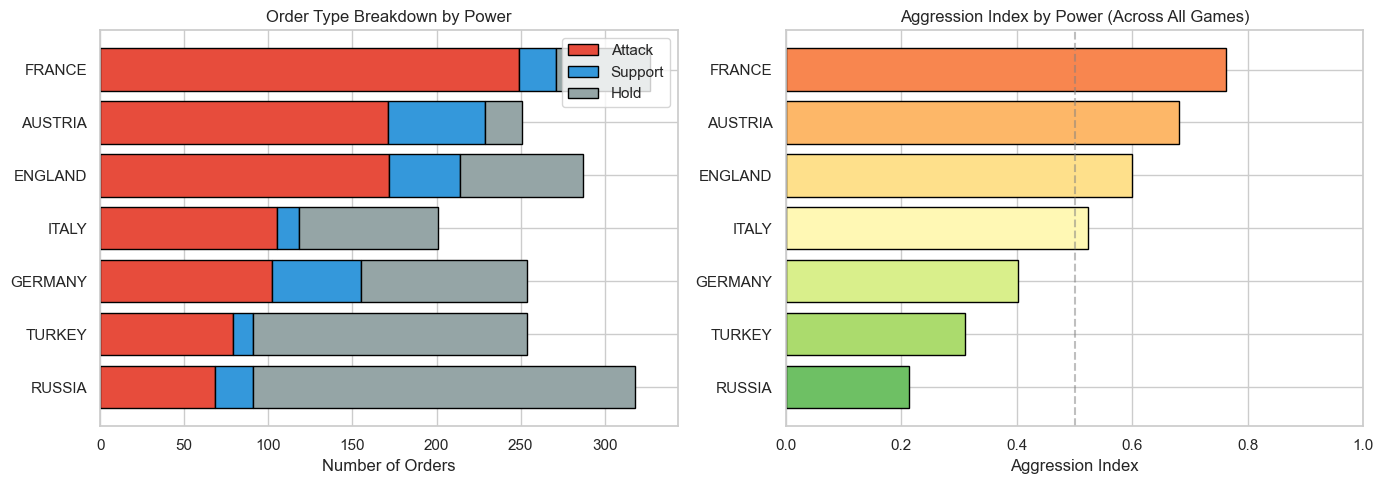

In [3]:
tactical = orders_df[orders_df["order_type"].isin(["attack", "support", "hold"])].copy()

power_tactics = tactical.groupby(["power", "order_type"]).size().unstack(fill_value=0)
for col in ["attack", "support", "hold"]:
    if col not in power_tactics.columns:
        power_tactics[col] = 0
power_tactics["total"] = power_tactics["attack"] + power_tactics["support"] + power_tactics["hold"]
power_tactics["aggression_index"] = power_tactics["attack"] / power_tactics["total"]
power_tactics["support_rate"] = power_tactics["support"] / power_tactics["total"]
power_tactics["hold_rate"] = power_tactics["hold"] / power_tactics["total"]
power_tactics = power_tactics.sort_values("aggression_index", ascending=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked horizontal bar
y_pos = range(len(power_tactics))
axes[0].barh(y_pos, power_tactics["attack"], label="Attack", color="#e74c3c", edgecolor="black")
axes[0].barh(y_pos, power_tactics["support"], left=power_tactics["attack"],
             label="Support", color="#3498db", edgecolor="black")
axes[0].barh(y_pos, power_tactics["hold"],
             left=power_tactics["attack"] + power_tactics["support"],
             label="Hold", color="#95a5a6", edgecolor="black")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(power_tactics["power"])
axes[0].set_xlabel("Number of Orders")
axes[0].set_title("Order Type Breakdown by Power")
axes[0].legend()

# Aggression index
colors = plt.cm.RdYlGn_r(power_tactics["aggression_index"])
axes[1].barh(power_tactics["power"], power_tactics["aggression_index"],
             color=colors, edgecolor="black")
axes[1].set_xlabel("Aggression Index")
axes[1].set_title("Aggression Index by Power (Across All Games)")
axes[1].set_xlim(0, 1)
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 1.2 Aggression Index by LLM Model
Since powers rotate across games, aggregating by model isolates the LLM's inherent playstyle from positional effects.

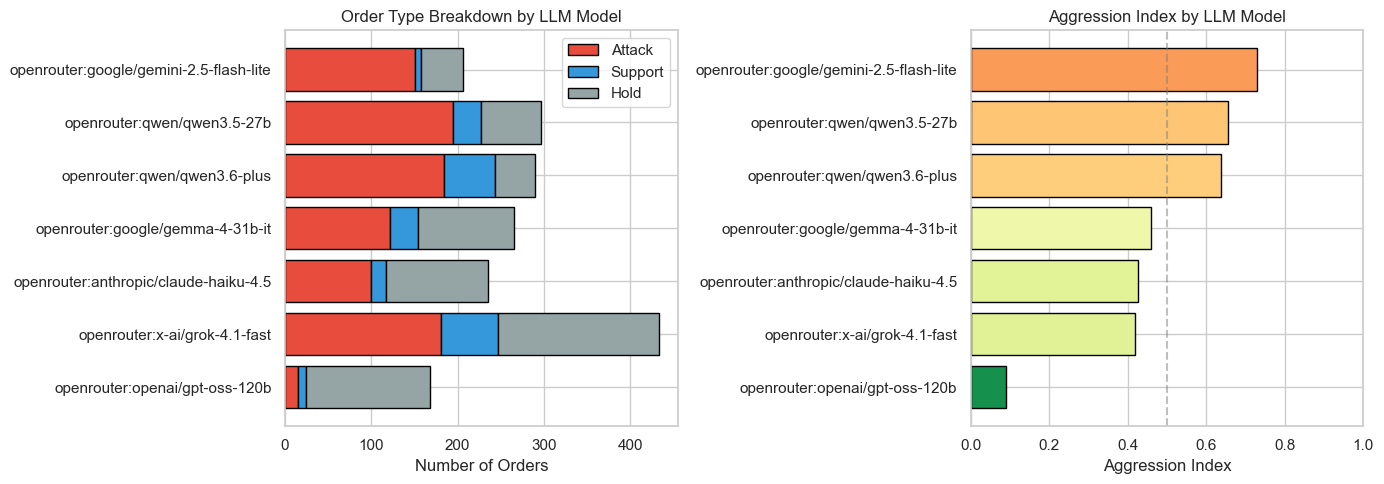

                             model_name  attack  support  hold  aggression_index  support_rate
         openrouter:openai/gpt-oss-120b      15        9   144          0.089286      0.053571
          openrouter:x-ai/grok-4.1-fast     181       66   186          0.418014      0.152425
  openrouter:anthropic/claude-haiku-4.5     100       17   118          0.425532      0.072340
       openrouter:google/gemma-4-31b-it     122       32   111          0.460377      0.120755
           openrouter:qwen/qwen3.6-plus     184       59    46          0.636678      0.204152
            openrouter:qwen/qwen3.5-27b     194       33    69          0.655405      0.111486
openrouter:google/gemini-2.5-flash-lite     150        7    49          0.728155      0.033981


In [4]:
tactical_with_model = pd.merge(tactical, model_df, on=["game", "power"], how="inner")

model_tactics = tactical_with_model.groupby(["model_name", "order_type"]).size().unstack(fill_value=0)
for col in ["attack", "support", "hold"]:
    if col not in model_tactics.columns:
        model_tactics[col] = 0
model_tactics["total"] = model_tactics["attack"] + model_tactics["support"] + model_tactics["hold"]
model_tactics["aggression_index"] = model_tactics["attack"] / model_tactics["total"]
model_tactics["support_rate"] = model_tactics["support"] / model_tactics["total"]
model_tactics = model_tactics.sort_values("aggression_index", ascending=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked horizontal bar (mirror of the power chart)
y_pos = range(len(model_tactics))
axes[0].barh(y_pos, model_tactics["attack"], label="Attack", color="#e74c3c", edgecolor="black")
axes[0].barh(y_pos, model_tactics["support"], left=model_tactics["attack"],
             label="Support", color="#3498db", edgecolor="black")
axes[0].barh(y_pos, model_tactics["hold"],
             left=model_tactics["attack"] + model_tactics["support"],
             label="Hold", color="#95a5a6", edgecolor="black")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(model_tactics["model_name"])
axes[0].set_xlabel("Number of Orders")
axes[0].set_title("Order Type Breakdown by LLM Model")
axes[0].legend()

# Aggression index
colors = plt.cm.RdYlGn_r(model_tactics["aggression_index"])
axes[1].barh(model_tactics["model_name"], model_tactics["aggression_index"],
             color=colors, edgecolor="black")
axes[1].set_xlabel("Aggression Index")
axes[1].set_title("Aggression Index by LLM Model")
axes[1].set_xlim(0, 1)
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(model_tactics[["model_name", "attack", "support", "hold", "aggression_index", "support_rate"]].to_string(index=False))

---
# 2. Playstyle Evolution Over Time
How does the aggression index change as the game progresses? In Diplomacy, early years tend to feature expansion into neutral supply centers, while later years involve direct conflict between powers.

## 2.1 Aggression Trajectory by Year (All Powers)

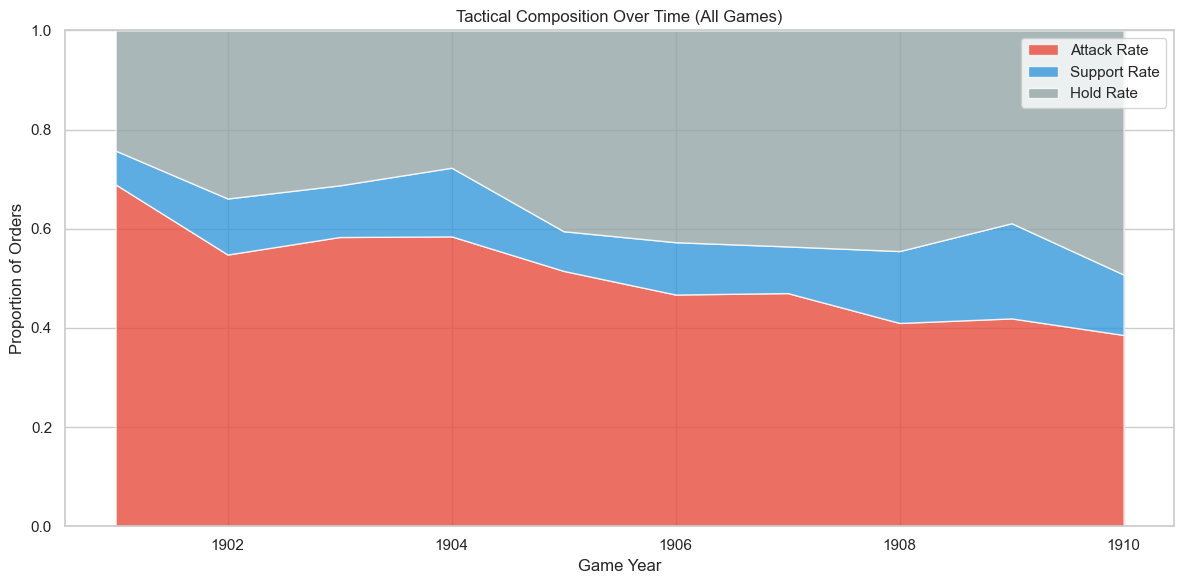

In [5]:
year_tactics = tactical.groupby(["year", "order_type"]).size().unstack(fill_value=0)
for col in ["attack", "support", "hold"]:
    if col not in year_tactics.columns:
        year_tactics[col] = 0
year_tactics["total"] = year_tactics["attack"] + year_tactics["support"] + year_tactics["hold"]
year_tactics["aggression_index"] = year_tactics["attack"] / year_tactics["total"]
year_tactics["support_rate"] = year_tactics["support"] / year_tactics["total"]
year_tactics["hold_rate"] = year_tactics["hold"] / year_tactics["total"]
year_tactics = year_tactics.reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(year_tactics["year"],
             year_tactics["aggression_index"],
             year_tactics["support_rate"],
             year_tactics["hold_rate"],
             labels=["Attack Rate", "Support Rate", "Hold Rate"],
             colors=["#e74c3c", "#3498db", "#95a5a6"], alpha=0.8)
ax.set_xlabel("Game Year")
ax.set_ylabel("Proportion of Orders")
ax.set_title("Tactical Composition Over Time (All Games)")
ax.legend(loc="upper right")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 2.1b Aggression Trajectory by Power
How does each individual power's aggression evolve over the game years?

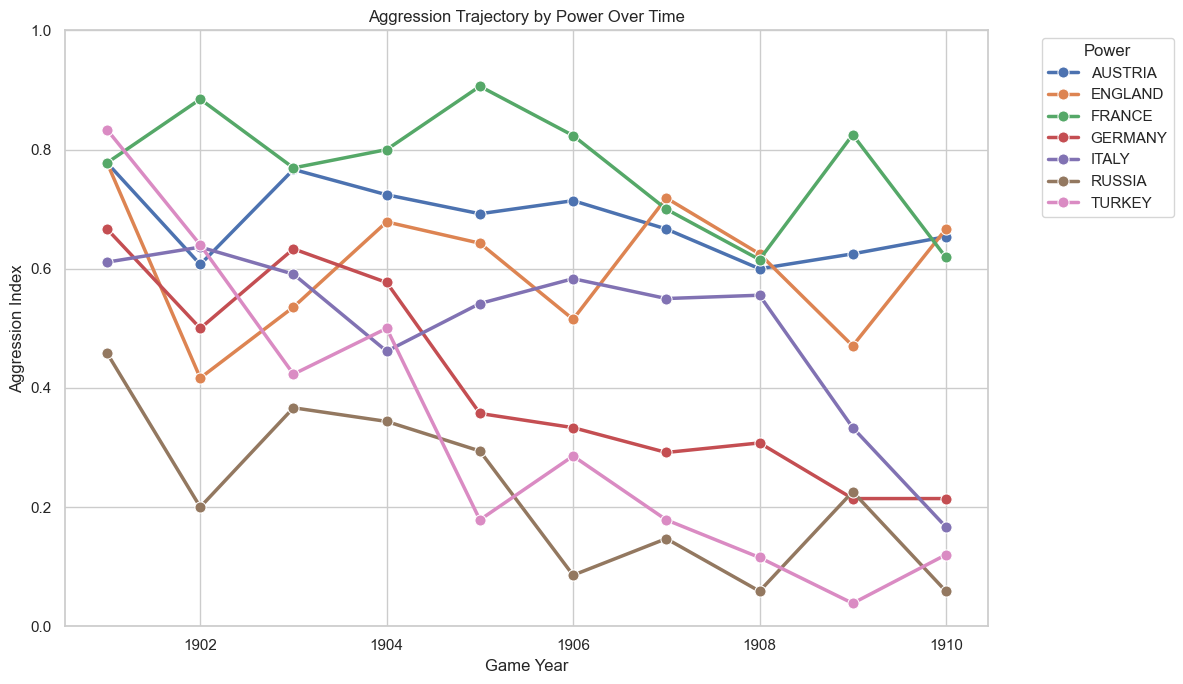

In [6]:
power_year_tactics = tactical.groupby(["power", "year", "order_type"]).size().reset_index(name="count")
power_year_pivot = power_year_tactics.pivot_table(index=["power", "year"], columns="order_type",
                                                   values="count", fill_value=0).reset_index()
for col in ["attack", "support", "hold"]:
    if col not in power_year_pivot.columns:
        power_year_pivot[col] = 0
power_year_pivot["total"] = power_year_pivot["attack"] + power_year_pivot["support"] + power_year_pivot["hold"]
power_year_pivot["aggression_index"] = power_year_pivot["attack"] / power_year_pivot["total"].replace(0, np.nan)

plt.figure(figsize=(12, 7))
sns.lineplot(data=power_year_pivot, x="year", y="aggression_index",
             hue="power", marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Aggression Index")
plt.title("Aggression Trajectory by Power Over Time")
plt.legend(title="Power", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 2.2 Aggression Trajectory by LLM Model
Do all models become more aggressive at the same rate, or do some maintain a passive posture while others escalate?

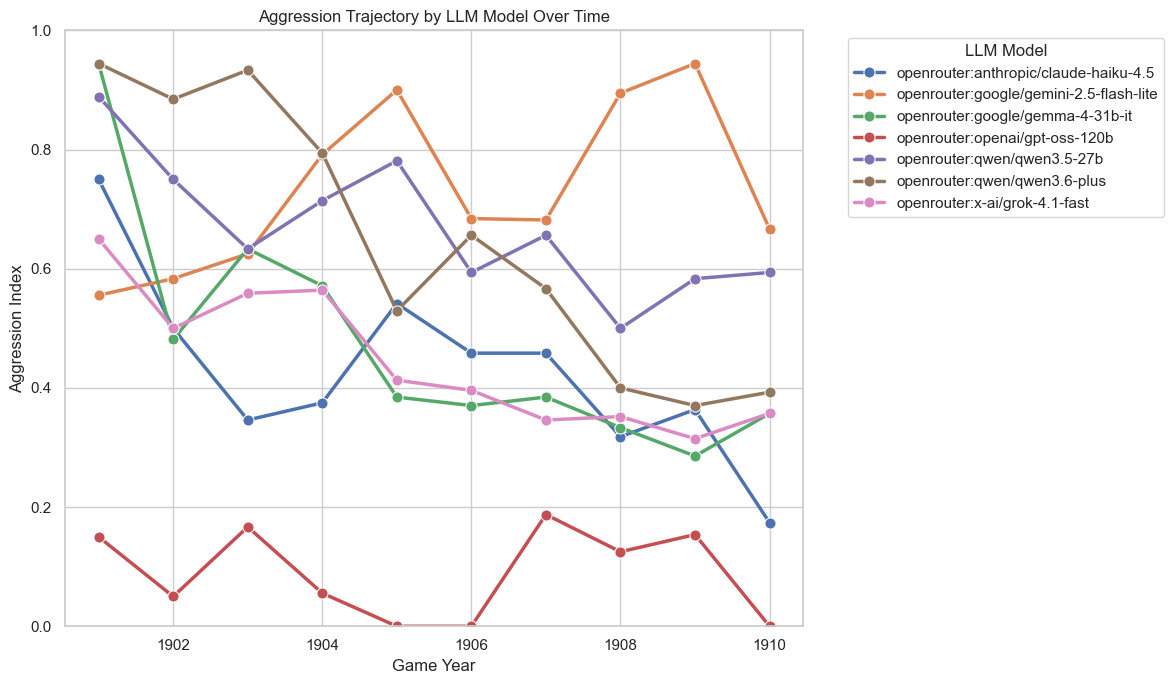

In [7]:
model_year_tactics = tactical_with_model.groupby(["model_name", "year", "order_type"]).size().reset_index(name="count")
model_year_pivot = model_year_tactics.pivot_table(index=["model_name", "year"], columns="order_type",
                                                   values="count", fill_value=0).reset_index()
for col in ["attack", "support", "hold"]:
    if col not in model_year_pivot.columns:
        model_year_pivot[col] = 0
model_year_pivot["total"] = model_year_pivot["attack"] + model_year_pivot["support"] + model_year_pivot["hold"]
model_year_pivot["aggression_index"] = model_year_pivot["attack"] / model_year_pivot["total"].replace(0, np.nan)

plt.figure(figsize=(12, 7))
sns.lineplot(data=model_year_pivot, x="year", y="aggression_index",
             hue="model_name", marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Aggression Index")
plt.title("Aggression Trajectory by LLM Model Over Time")
plt.legend(title="LLM Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

---
# 3. Diplomatic Engagement
Beyond orders, playstyle is also reflected in how actively a power communicates. Heavy communicators may be diplomatic/cooperative, while silent powers may be playing a lone-wolf strategy.

## 3.1 Messaging Volume by Power and Model

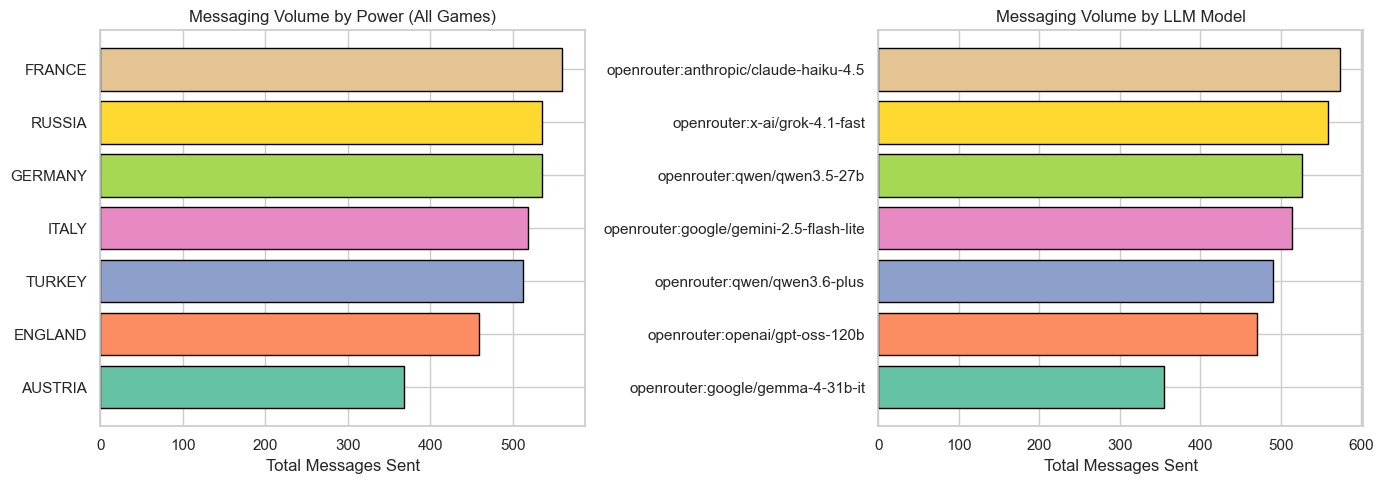

In [8]:
# Extract all messages
all_messages = []
for game, gdata in game_data_all.items():
    for phase in gdata.get("phases", []):
        phase_name = phase["name"]
        year_match = re.search(r"(19\d{2})", phase_name)
        year = int(year_match.group(1)) if year_match else None
        for msg in phase.get("messages", []):
            all_messages.append({
                "game": game, "phase": phase_name, "year": year,
                "sender": msg.get("sender", ""),
                "recipient": msg.get("recipient", ""),
                "message": msg.get("message", ""),
                "msg_len": len(msg.get("message", ""))
            })

msg_df = pd.DataFrame(all_messages)
msg_with_model = pd.merge(msg_df, model_df, left_on=["game", "sender"],
                           right_on=["game", "power"], how="inner")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Messages per power
power_msg = msg_df.groupby("sender").size().sort_values(ascending=True).reset_index(name="count")
axes[0].barh(power_msg["sender"], power_msg["count"], color=sns.color_palette("Set2", len(power_msg)),
             edgecolor="black")
axes[0].set_xlabel("Total Messages Sent")
axes[0].set_title("Messaging Volume by Power (All Games)")

# Messages per model
model_msg = msg_with_model.groupby("model_name").size().sort_values(ascending=True).reset_index(name="count")
axes[1].barh(model_msg["model_name"], model_msg["count"],
             color=sns.color_palette("Set2", len(model_msg)), edgecolor="black")
axes[1].set_xlabel("Total Messages Sent")
axes[1].set_title("Messaging Volume by LLM Model")

plt.tight_layout()
plt.show()

## 3.2 Diplomatic Reach: Who Talks to Whom?
A power that messages all other powers is casting a wide diplomatic net. One that only messages a single neighbor may be tunnel-visioned.

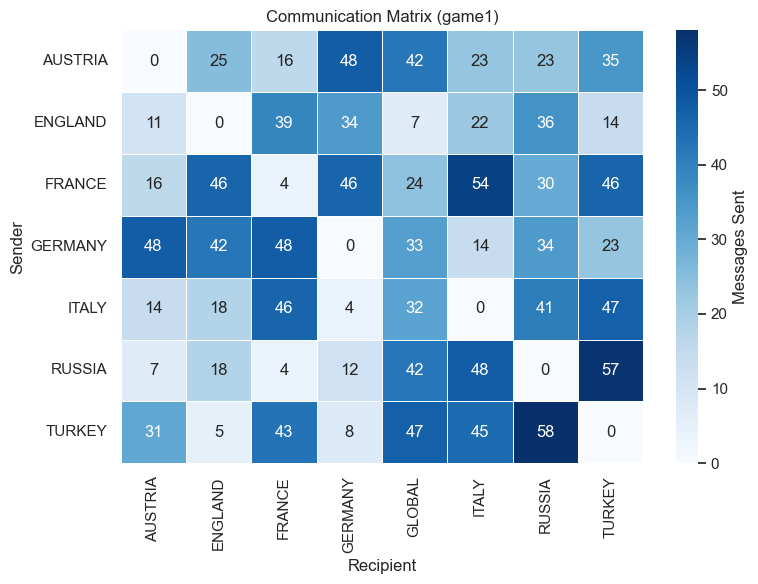

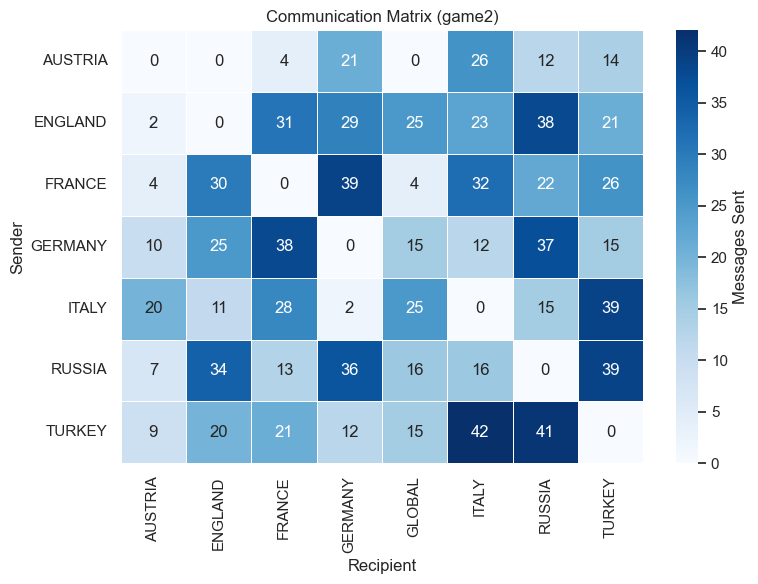

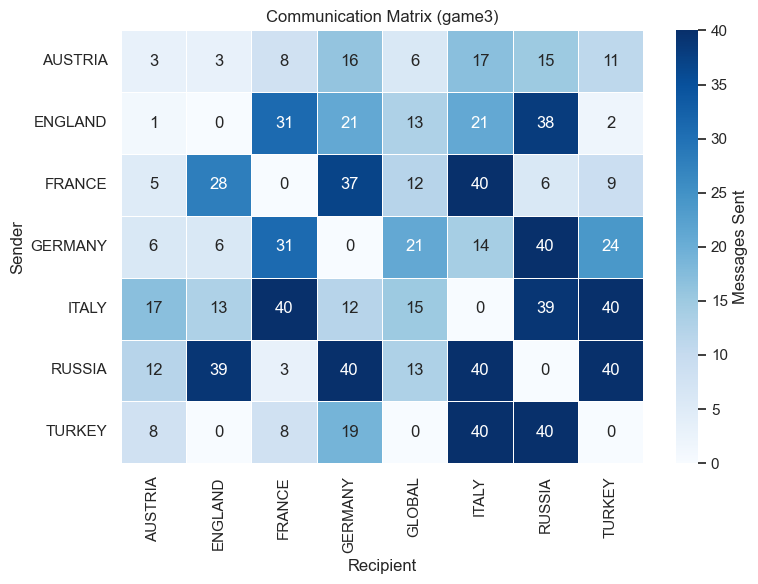

In [9]:
# Communication matrix: sender -> recipient count
for game in games:
    game_msgs = msg_df[msg_df["game"] == game]
    if game_msgs.empty:
        continue
    comm_matrix = game_msgs.groupby(["sender", "recipient"]).size().reset_index(name="count")
    pivot = comm_matrix.pivot(index="sender", columns="recipient", values="count").fillna(0)

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5,
                cbar_kws={"label": "Messages Sent"})
    plt.title(f"Communication Matrix ({game})")
    plt.ylabel("Sender")
    plt.xlabel("Recipient")
    plt.tight_layout()
    plt.show()

## 3.2b Diplomatic Reach by LLM Model: Who Talks to Whom?
The same communication matrix but with sender/recipient mapped to their underlying LLM model. This reveals whether certain model architectures preferentially communicate with specific other models.

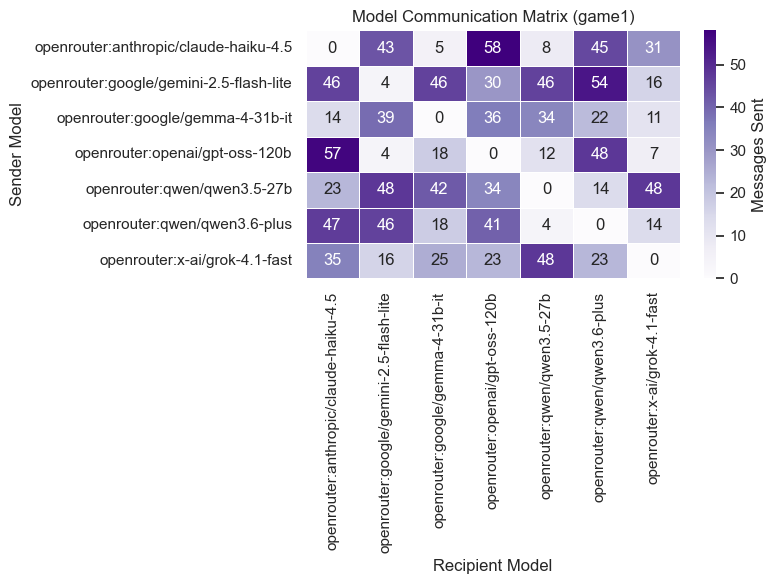

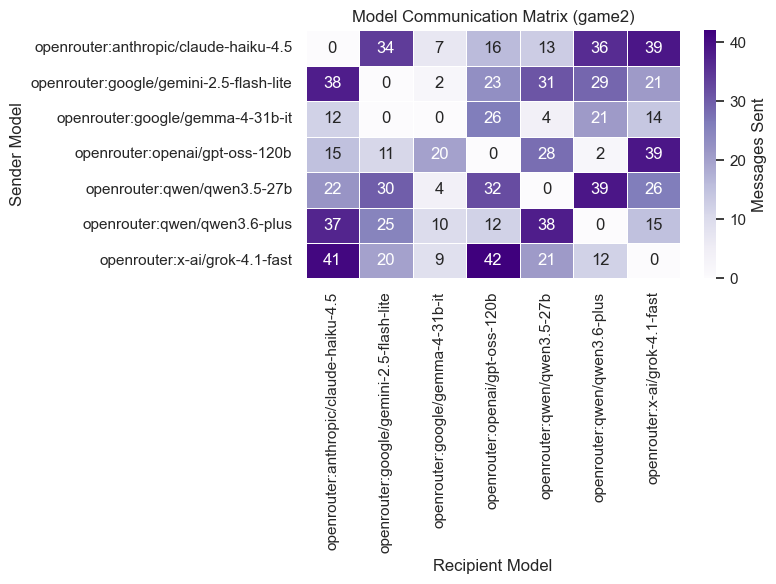

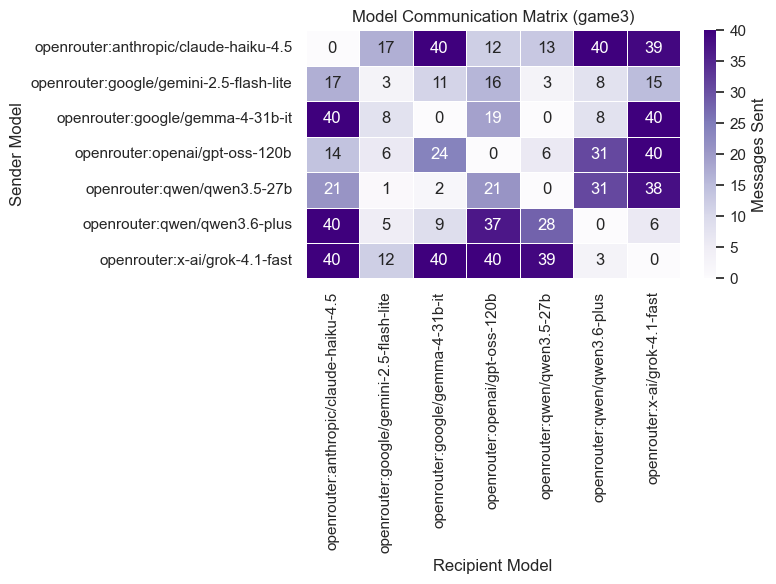

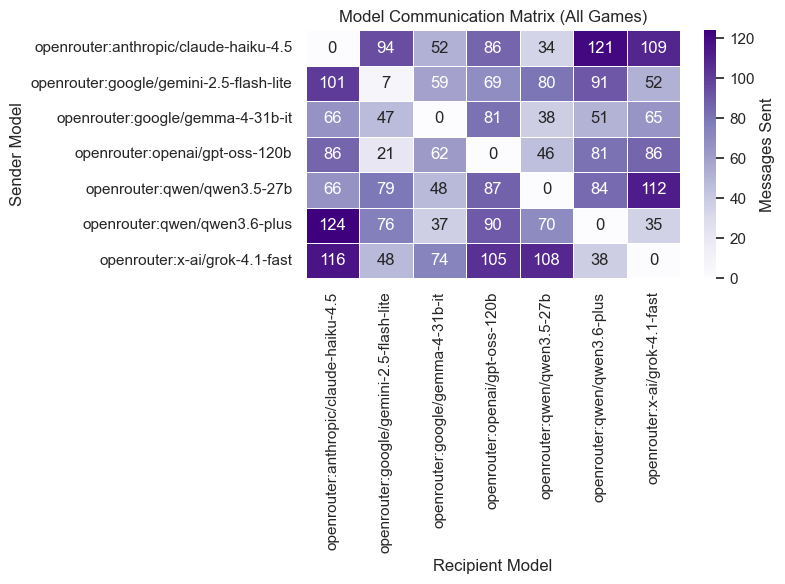

In [10]:
# Map both sender and recipient to their LLM model
msg_sender_model = pd.merge(msg_df, model_df, left_on=["game", "sender"],
                             right_on=["game", "power"], how="inner")
msg_sender_model.rename(columns={"model_name": "sender_model"}, inplace=True)
msg_both_model = pd.merge(msg_sender_model, model_df, left_on=["game", "recipient"],
                           right_on=["game", "power"], how="inner", suffixes=("", "_recv"))
msg_both_model.rename(columns={"model_name": "recipient_model"}, inplace=True)

# Per-game model communication matrix
for game in games:
    game_msgs = msg_both_model[msg_both_model["game"] == game]
    if game_msgs.empty:
        continue
    comm_matrix = game_msgs.groupby(["sender_model", "recipient_model"]).size().reset_index(name="count")
    pivot = comm_matrix.pivot(index="sender_model", columns="recipient_model", values="count").fillna(0)

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5,
                cbar_kws={"label": "Messages Sent"})
    plt.title(f"Model Communication Matrix ({game})")
    plt.ylabel("Sender Model")
    plt.xlabel("Recipient Model")
    plt.tight_layout()
    plt.show()

# Aggregated across all games
comm_all = msg_both_model.groupby(["sender_model", "recipient_model"]).size().reset_index(name="count")
pivot_all = comm_all.pivot(index="sender_model", columns="recipient_model", values="count").fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_all, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5,
            cbar_kws={"label": "Messages Sent"})
plt.title("Model Communication Matrix (All Games)")
plt.ylabel("Sender Model")
plt.xlabel("Recipient Model")
plt.tight_layout()
plt.show()

## 3.3 Messaging Activity Over Time
Does diplomatic engagement increase or decrease as the game progresses?

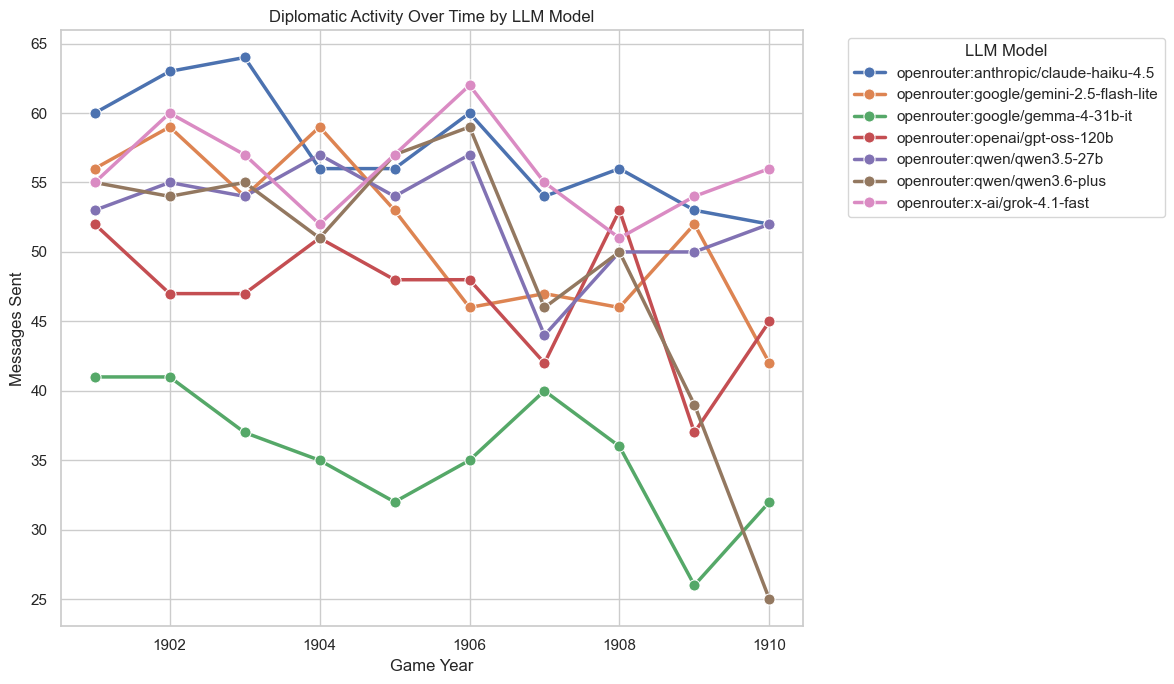

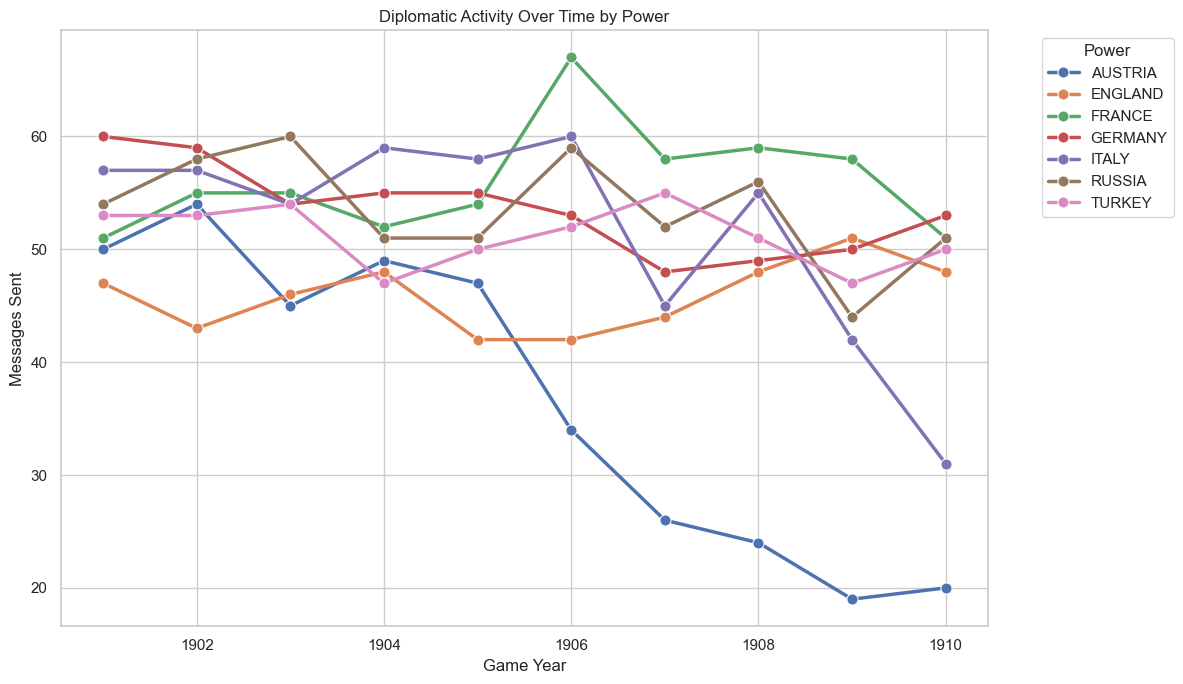

In [11]:
# By model
msg_by_year_model = msg_with_model.groupby(["model_name", "year"]).size().reset_index(name="messages")

plt.figure(figsize=(12, 7))
sns.lineplot(data=msg_by_year_model, x="year", y="messages",
             hue="model_name", marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Messages Sent")
plt.title("Diplomatic Activity Over Time by LLM Model")
plt.legend(title="LLM Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# By power
msg_by_year_power = msg_df.groupby(["sender", "year"]).size().reset_index(name="messages")

plt.figure(figsize=(12, 7))
sns.lineplot(data=msg_by_year_power, x="year", y="messages",
             hue="sender", marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Messages Sent")
plt.title("Diplomatic Activity Over Time by Power")
plt.legend(title="Power", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
# 4. Relationship Dynamics
Each agent maintains explicit relationship labels (Ally, Friendly, Neutral, Unfriendly, Enemy) for every other power. These are updated by the LLM each phase based on board events and negotiations.

## 4.1 Relationship Distribution by Power

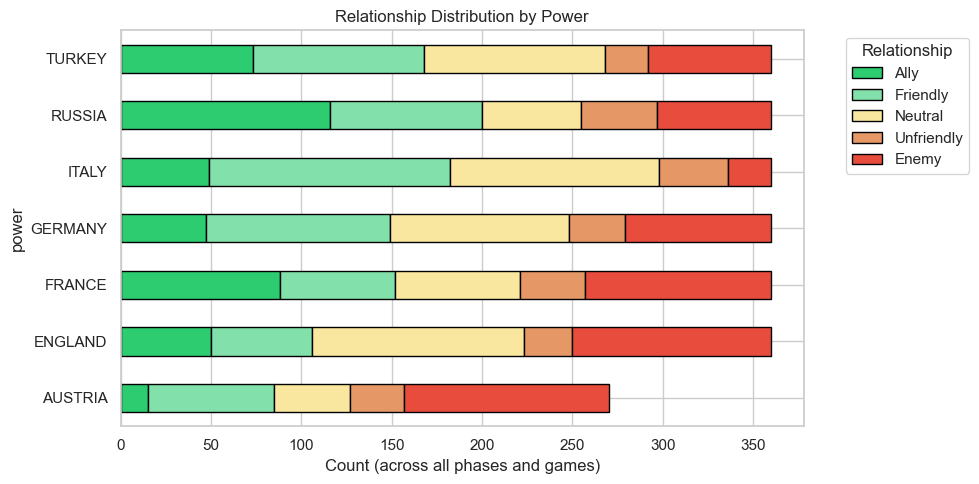

In [12]:
# Extract relationships from state_agents
all_rels = []
for game, gdata in game_data_all.items():
    for phase in gdata.get("phases", []):
        phase_name = phase["name"]
        if not phase_name.endswith("M"):
            continue
        year_match = re.search(r"(19\d{2})", phase_name)
        year = int(year_match.group(1)) if year_match else None
        for power, agent in phase.get("state_agents", {}).items():
            for target, rel in agent.get("relationships", {}).items():
                all_rels.append({
                    "game": game, "phase": phase_name, "year": year,
                    "power": power, "target": target, "relationship": rel
                })

rel_df = pd.DataFrame(all_rels)

rel_order = ["Ally", "Friendly", "Neutral", "Unfriendly", "Enemy"]
rel_colors = {"Ally": "#2ecc71", "Friendly": "#82e0aa", "Neutral": "#f9e79f",
              "Unfriendly": "#e59866", "Enemy": "#e74c3c"}

power_rel_counts = rel_df.groupby(["power", "relationship"]).size().unstack(fill_value=0)
power_rel_counts = power_rel_counts.reindex(columns=rel_order, fill_value=0)

power_rel_counts.plot(kind="barh", stacked=True, figsize=(10, 5),
                       color=[rel_colors[r] for r in power_rel_counts.columns],
                       edgecolor="black")
plt.xlabel("Count (across all phases and games)")
plt.title("Relationship Distribution by Power")
plt.legend(title="Relationship", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4.1b Relationship Distribution by LLM Model

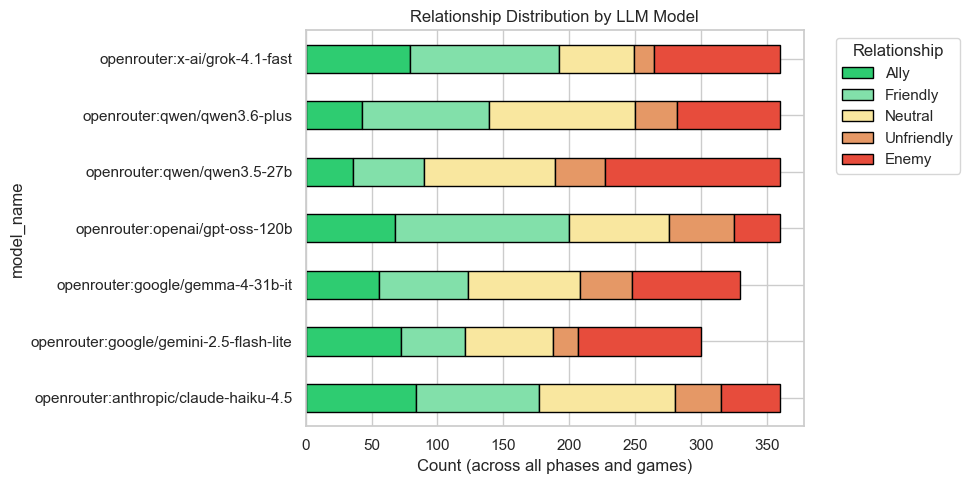

In [13]:
rel_with_model_full = pd.merge(rel_df, model_df, on=["game", "power"], how="inner")

model_rel_counts = rel_with_model_full.groupby(["model_name", "relationship"]).size().unstack(fill_value=0)
model_rel_counts = model_rel_counts.reindex(columns=rel_order, fill_value=0)

model_rel_counts.plot(kind="barh", stacked=True, figsize=(10, 5),
                       color=[rel_colors[r] for r in model_rel_counts.columns],
                       edgecolor="black")
plt.xlabel("Count (across all phases and games)")
plt.title("Relationship Distribution by LLM Model")
plt.legend(title="Relationship", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4.2 Relationship Evolution Over Time
How do relationships shift as the game progresses? We assign a numeric value to each relationship label and track the average "warmth" over time.

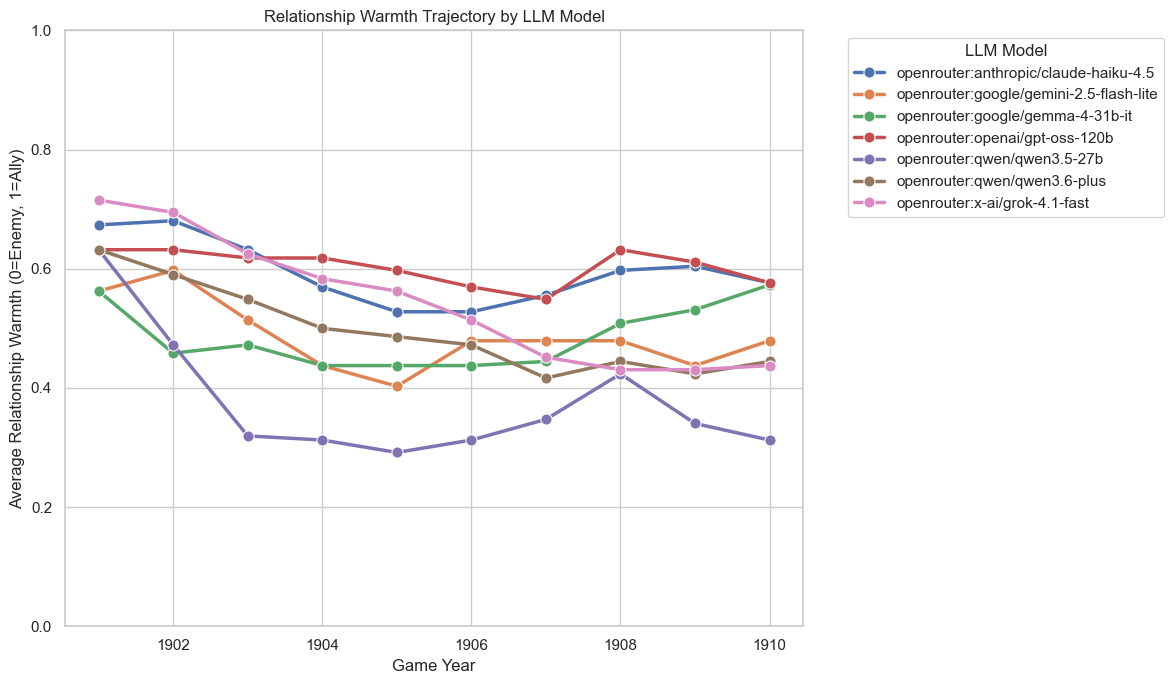

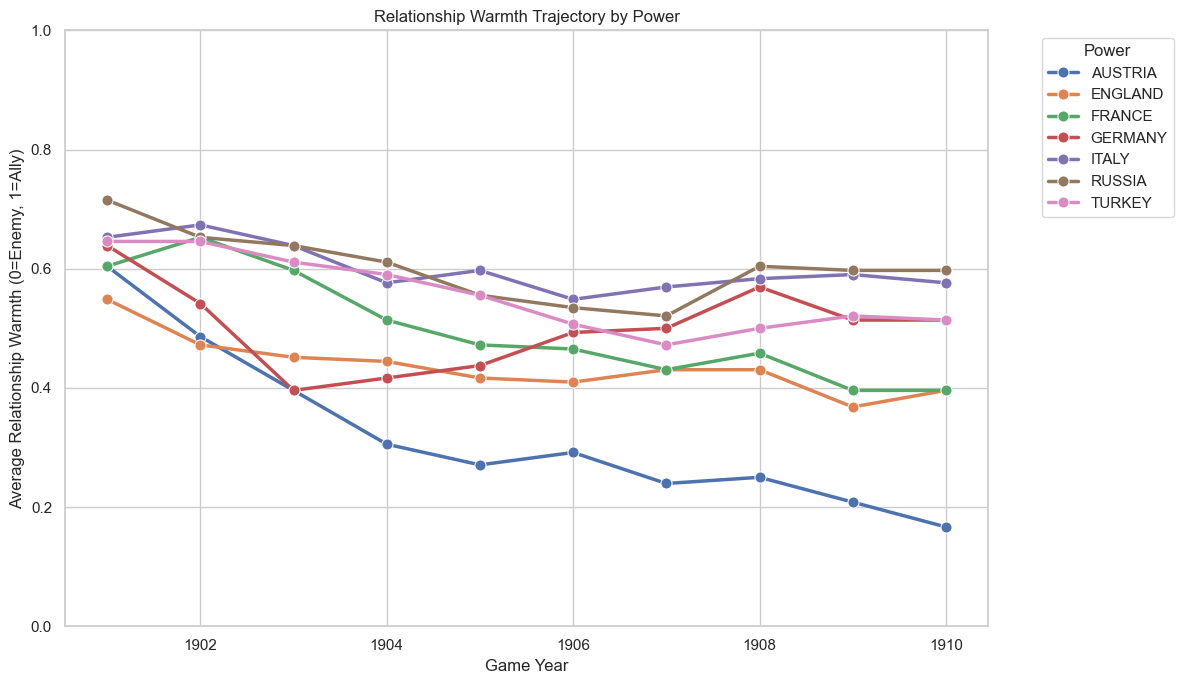

In [14]:
rel_numeric = {"Ally": 1.0, "Friendly": 0.75, "Neutral": 0.5, "Unfriendly": 0.25, "Enemy": 0.0}
rel_df["warmth"] = rel_df["relationship"].map(rel_numeric)

rel_with_model = pd.merge(rel_df, model_df, on=["game", "power"], how="inner")

# By model
model_year_warmth = rel_with_model.groupby(["model_name", "year"])["warmth"].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=model_year_warmth, x="year", y="warmth",
             hue="model_name", marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Average Relationship Warmth (0=Enemy, 1=Ally)")
plt.title("Relationship Warmth Trajectory by LLM Model")
plt.legend(title="LLM Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# By power
power_year_warmth = rel_df.groupby(["power", "year"])["warmth"].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=power_year_warmth, x="year", y="warmth",
             hue="power", marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Average Relationship Warmth (0=Enemy, 1=Ally)")
plt.title("Relationship Warmth Trajectory by Power")
plt.legend(title="Power", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 4.3 Relationship Reciprocity
Does Power A labeling Power B as "Ally" mean B labels A the same way? Asymmetric relationships reveal diplomatic blind spots.

In [15]:
# Match A->B with B->A in same game/phase
rel_pairs = pd.merge(rel_df, rel_df,
                      left_on=["game", "phase", "power", "target"],
                      right_on=["game", "phase", "target", "power"],
                      suffixes=("_ab", "_ba"))
rel_pairs["warmth_gap"] = abs(rel_pairs["warmth_ab"] - rel_pairs["warmth_ba"])

# Avoid double-counting A-B and B-A
rel_pairs_dedup = rel_pairs[rel_pairs["power_ab"] < rel_pairs["target_ab"]].copy()

print(f"Average relationship reciprocity gap: {rel_pairs_dedup['warmth_gap'].mean():.3f}")
print(f"\nTop 10 most asymmetric relationships:")
top_asym = rel_pairs_dedup.nlargest(10, "warmth_gap")[
    ["game", "phase", "power_ab", "target_ab", "relationship_ab", "relationship_ba", "warmth_gap"]
]
print(top_asym.to_string(index=False))

Average relationship reciprocity gap: 0.141

Top 10 most asymmetric relationships:
 game  phase power_ab target_ab relationship_ab relationship_ba  warmth_gap
game1 F1904M  AUSTRIA    FRANCE            Ally           Enemy        1.00
game1 S1905M  AUSTRIA    FRANCE            Ally           Enemy        1.00
game1 F1905M  AUSTRIA    FRANCE            Ally           Enemy        1.00
game1 S1906M  AUSTRIA    FRANCE            Ally           Enemy        1.00
game1 S1903M  ENGLAND    RUSSIA            Ally      Unfriendly        0.75
game1 F1903M  ENGLAND    RUSSIA            Ally      Unfriendly        0.75
game1 S1904M  ENGLAND    RUSSIA            Ally      Unfriendly        0.75
game1 F1904M   FRANCE    RUSSIA            Ally      Unfriendly        0.75
game1 F1904M   RUSSIA    TURKEY            Ally      Unfriendly        0.75
game1 S1905M   FRANCE    RUSSIA            Ally      Unfriendly        0.75


## 4.3b Relationship Asymmetry by LLM Model
Which models have the largest gap between how they view others and how others view them? A high asymmetry score means the model's perception of its relationships is systematically misaligned with reality.

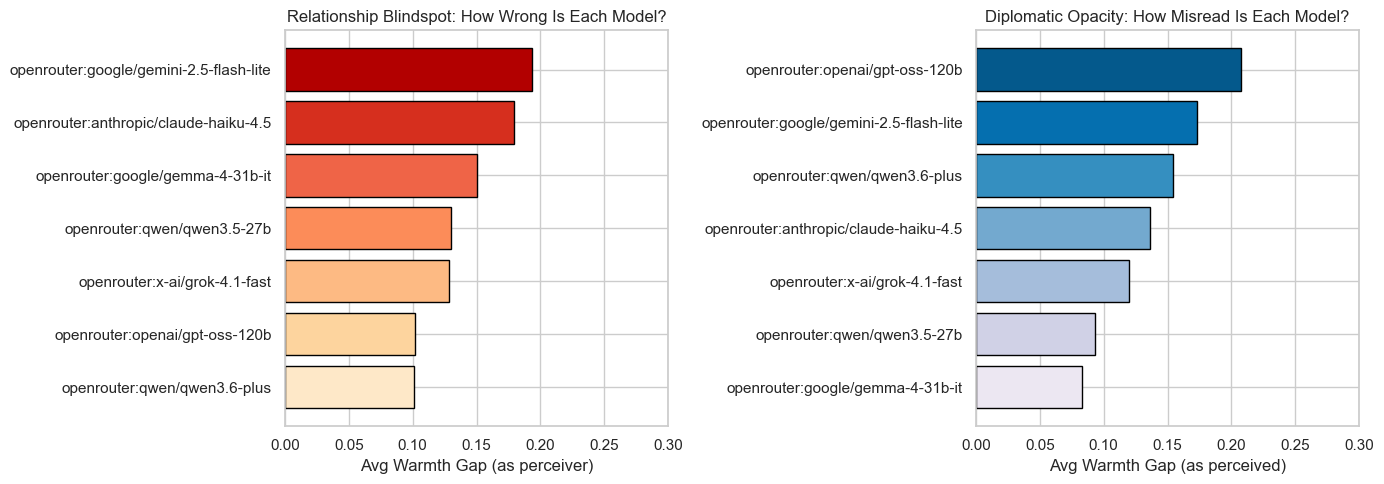

Top 10 most asymmetric model-model relationships (avg warmth gap):
                               model_ab                                model_ba  warmth_gap
openrouter:google/gemini-2.5-flash-lite          openrouter:openai/gpt-oss-120b    0.385000
       openrouter:google/gemma-4-31b-it          openrouter:openai/gpt-oss-120b    0.307143
          openrouter:x-ai/grok-4.1-fast openrouter:google/gemini-2.5-flash-lite    0.262500
       openrouter:google/gemma-4-31b-it            openrouter:qwen/qwen3.6-plus    0.214286
  openrouter:anthropic/claude-haiku-4.5           openrouter:x-ai/grok-4.1-fast    0.206250
         openrouter:openai/gpt-oss-120b   openrouter:anthropic/claude-haiku-4.5    0.183333
openrouter:google/gemini-2.5-flash-lite   openrouter:anthropic/claude-haiku-4.5    0.180000
openrouter:google/gemini-2.5-flash-lite            openrouter:qwen/qwen3.6-plus    0.165000
          openrouter:x-ai/grok-4.1-fast        openrouter:google/gemma-4-31b-it    0.162500
            o

In [16]:
# Add model info to both sides of the relationship pair
pairs_with_model_ab = pd.merge(rel_pairs_dedup, model_df,
                                left_on=["game", "power_ab"], right_on=["game", "power"], how="inner")
pairs_with_model_ab.rename(columns={"model_name": "model_ab"}, inplace=True)
pairs_with_model = pd.merge(pairs_with_model_ab, model_df,
                              left_on=["game", "target_ab"], right_on=["game", "power"], how="inner",
                              suffixes=("", "_target"))
pairs_with_model.rename(columns={"model_name": "model_ba"}, inplace=True)

# Average asymmetry where each model is the "perceiver" (power_ab)
model_asym_as_perceiver = pairs_with_model.groupby("model_ab")["warmth_gap"].mean().reset_index()
model_asym_as_perceiver.columns = ["model_name", "avg_gap_as_perceiver"]

# Average asymmetry where each model is the "perceived" (target_ab = power_ba)
model_asym_as_perceived = pairs_with_model.groupby("model_ba")["warmth_gap"].mean().reset_index()
model_asym_as_perceived.columns = ["model_name", "avg_gap_as_perceived"]

model_asym = pd.merge(model_asym_as_perceiver, model_asym_as_perceived, on="model_name", how="outer").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: avg asymmetry by model (as perceiver — how wrong is this model about its relationships?)
model_asym_sorted = model_asym.sort_values("avg_gap_as_perceiver", ascending=True)
axes[0].barh(model_asym_sorted["model_name"], model_asym_sorted["avg_gap_as_perceiver"],
             color=sns.color_palette("OrRd", len(model_asym_sorted)), edgecolor="black")
axes[0].set_xlabel("Avg Warmth Gap (as perceiver)")
axes[0].set_title("Relationship Blindspot: How Wrong Is Each Model?")
axes[0].set_xlim(0, max(model_asym_sorted["avg_gap_as_perceiver"].max() * 1.3, 0.3))

# Bar: avg asymmetry by model (as perceived — how misread is this model by others?)
model_asym_sorted2 = model_asym.sort_values("avg_gap_as_perceived", ascending=True)
axes[1].barh(model_asym_sorted2["model_name"], model_asym_sorted2["avg_gap_as_perceived"],
             color=sns.color_palette("PuBu", len(model_asym_sorted2)), edgecolor="black")
axes[1].set_xlabel("Avg Warmth Gap (as perceived)")
axes[1].set_title("Diplomatic Opacity: How Misread Is Each Model?")
axes[1].set_xlim(0, max(model_asym_sorted2["avg_gap_as_perceived"].max() * 1.3, 0.3))

plt.tight_layout()
plt.show()

# Top asymmetric model-model pairs
model_pair_asym = pairs_with_model.groupby(["model_ab", "model_ba"])["warmth_gap"].mean().reset_index()
model_pair_asym = model_pair_asym.sort_values("warmth_gap", ascending=False)
print("Top 10 most asymmetric model-model relationships (avg warmth gap):")
print(model_pair_asym.head(10).to_string(index=False))

---
# 5. Territorial Expansion Patterns
The supply center trajectory is the ultimate measure of playstyle effectiveness. We track how each power's territory grows or shrinks over time.

## 5.1 Supply Center Trajectories

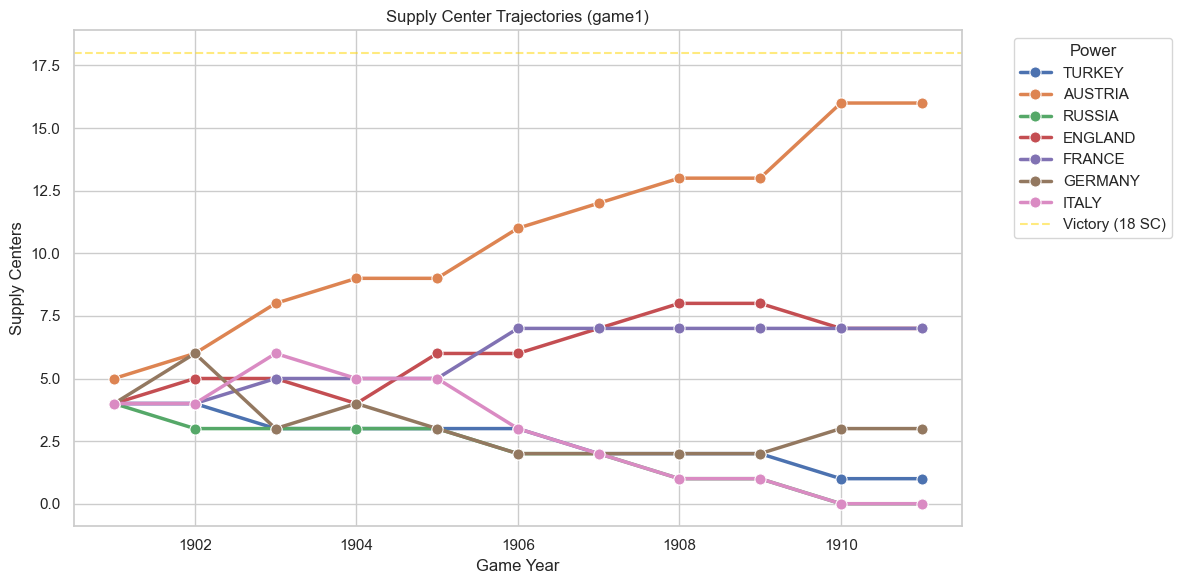

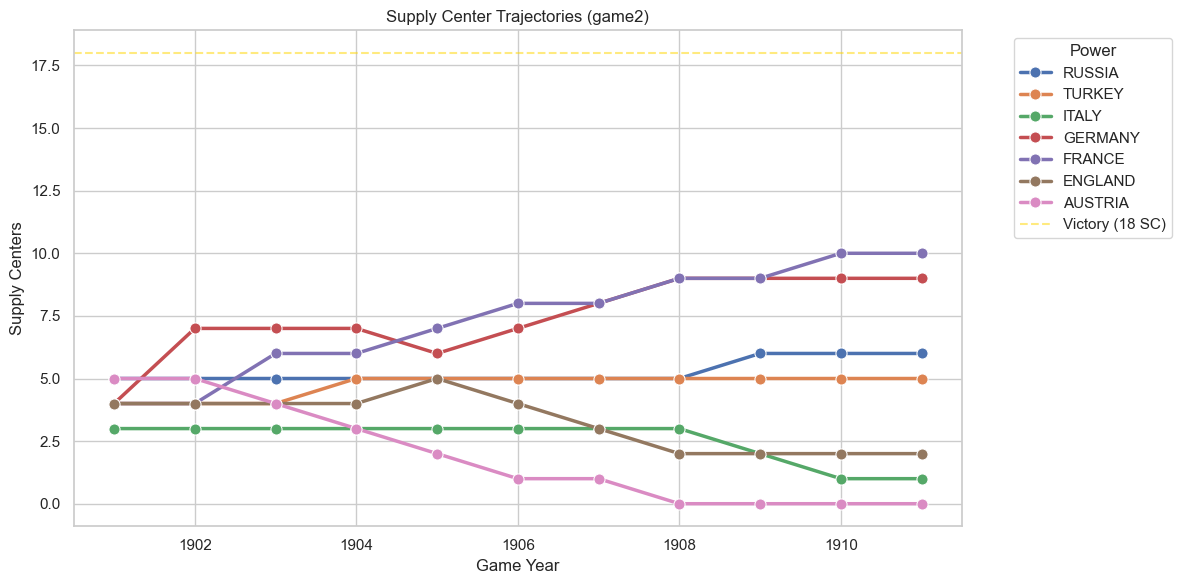

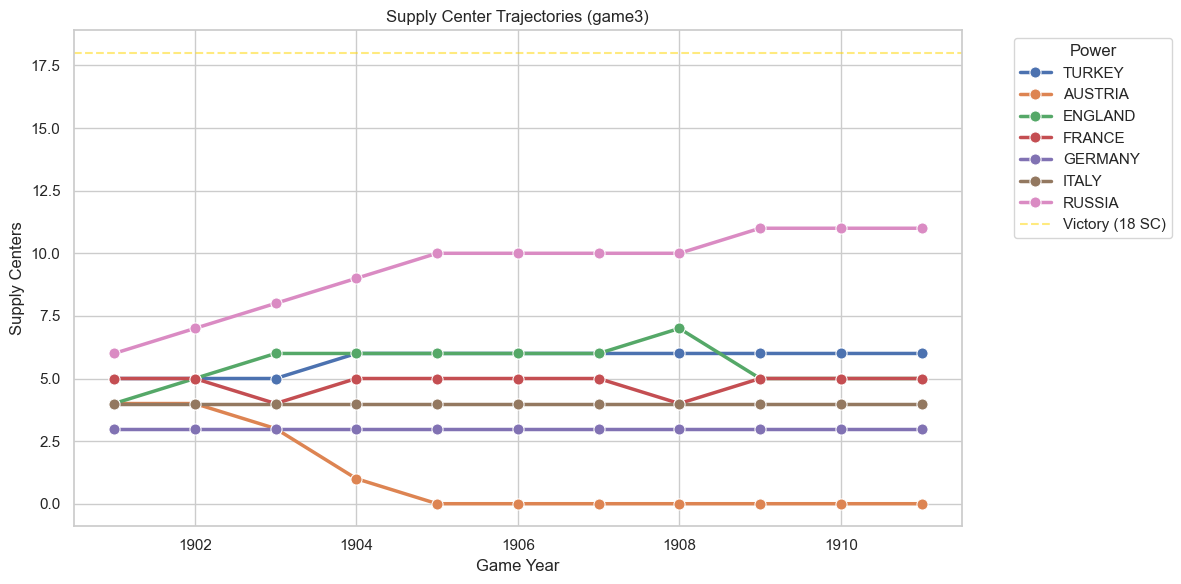

In [17]:
# Extract SC counts per phase
sc_trajectories = []
for game, gdata in game_data_all.items():
    for phase in gdata.get("phases", []):
        phase_name = phase["name"]
        year_match = re.search(r"(19\d{2})", phase_name)
        year = int(year_match.group(1)) if year_match else None
        centers = phase.get("state", {}).get("centers", {})
        for power, sc_list in centers.items():
            sc_trajectories.append({
                "game": game, "phase": phase_name, "year": year,
                "power": power, "sc_count": len(sc_list)
            })

traj_df = pd.DataFrame(sc_trajectories)

# Plot per game
for game in games:
    game_traj = traj_df[traj_df["game"] == game]
    if game_traj.empty:
        continue
    # Take the last phase entry per year per power
    yearly = game_traj.sort_values("phase").drop_duplicates(
        subset=["power", "year"], keep="last")

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=yearly, x="year", y="sc_count", hue="power",
                 marker="o", linewidth=2.5, markersize=8)
    plt.axhline(18, color="gold", linestyle="--", alpha=0.5, label="Victory (18 SC)")
    plt.xlabel("Game Year")
    plt.ylabel("Supply Centers")
    plt.title(f"Supply Center Trajectories ({game})")
    plt.legend(title="Power", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 5.2 Expansion Rate by Model
Which LLM models expand territory fastest? We measure the average supply center gain from game start to game end.

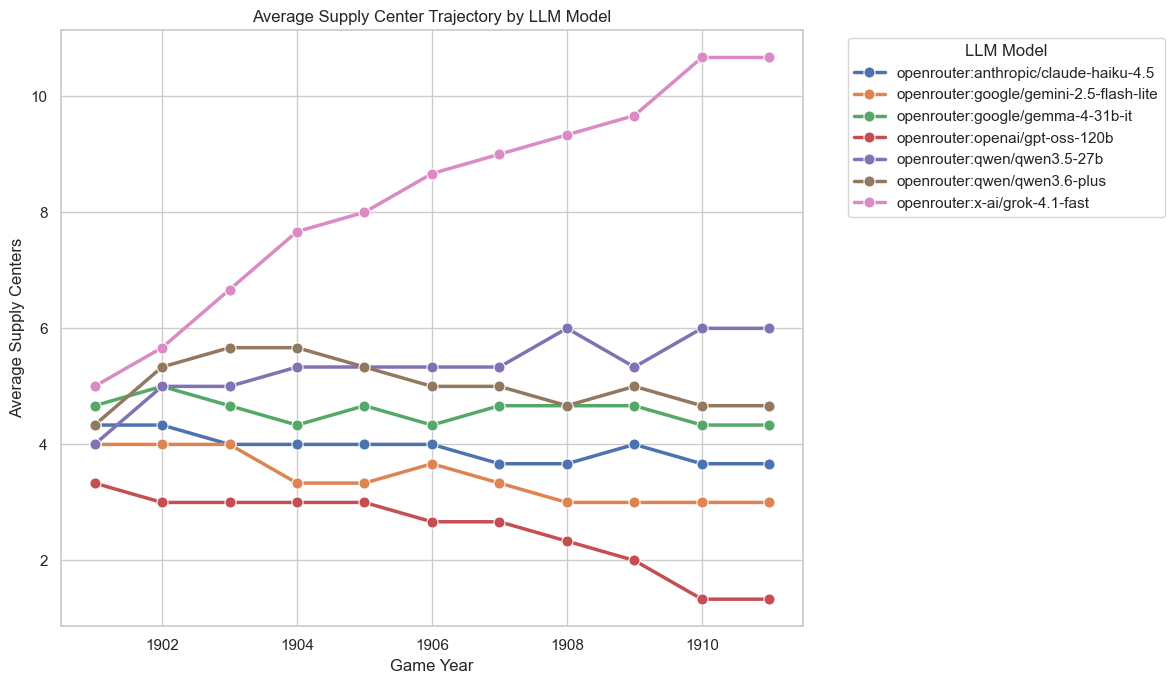

In [18]:
traj_with_model = pd.merge(traj_df, model_df, on=["game", "power"], how="inner")

# Average SC by model by year
model_traj = traj_with_model.sort_values("phase").drop_duplicates(
    subset=["game", "power", "year"], keep="last")
model_year_sc = model_traj.groupby(["model_name", "year"])["sc_count"].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=model_year_sc, x="year", y="sc_count",
             hue="model_name", marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Average Supply Centers")
plt.title("Average Supply Center Trajectory by LLM Model")
plt.legend(title="LLM Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5.2b Average Expansion Rate by Power
The same view aggregated by power rather than model — showing whether certain board positions inherently expand faster.

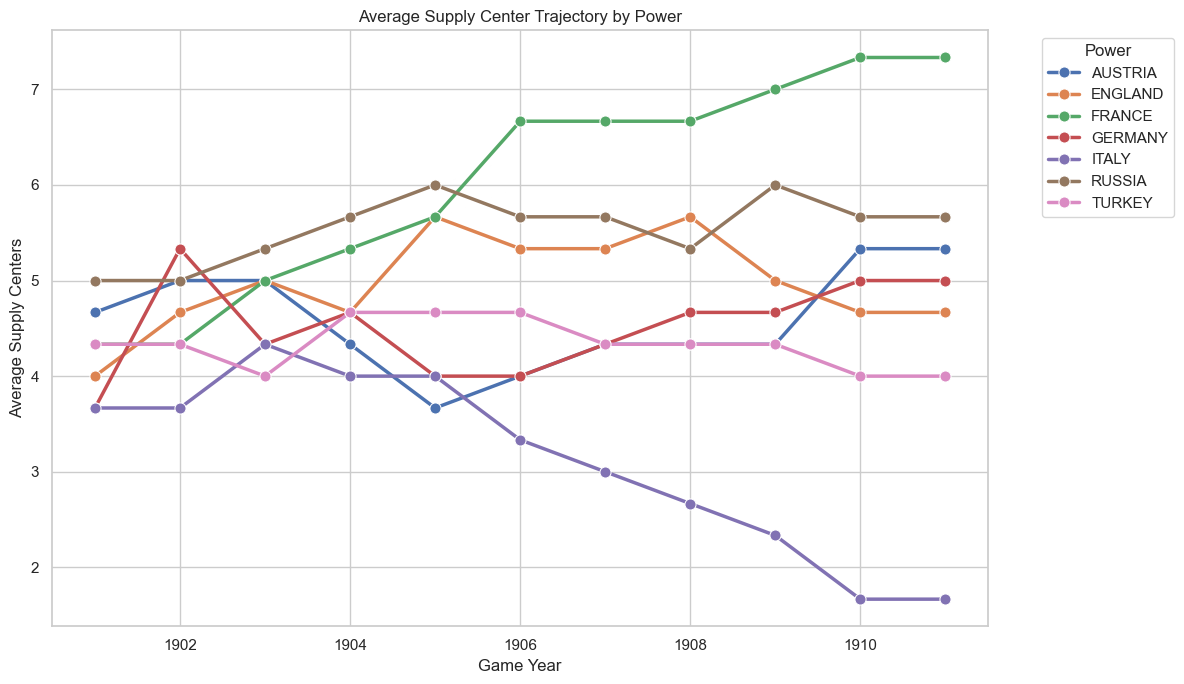

In [19]:
power_traj = traj_df.sort_values("phase").drop_duplicates(
    subset=["game", "power", "year"], keep="last")
power_year_sc = power_traj.groupby(["power", "year"])["sc_count"].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=power_year_sc, x="year", y="sc_count",
             hue="power", marker="o", linewidth=2.5, markersize=8)
plt.xlabel("Game Year")
plt.ylabel("Average Supply Centers")
plt.title("Average Supply Center Trajectory by Power")
plt.legend(title="Power", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
# 6. Cross-Game Adaptation (Memory Effect)
Games 2 and 3 inject memories from the prior game. Does this change playstyle? We compare aggression, diplomacy, and relationship warmth across the three games to see if agents learn and adapt.

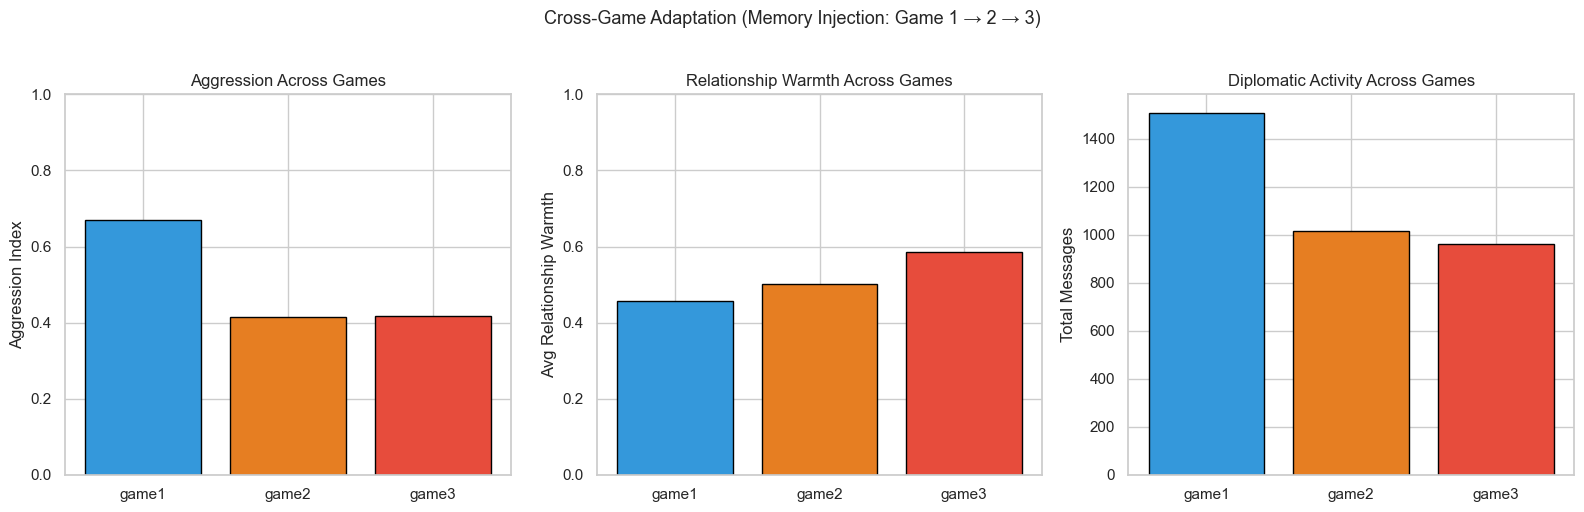

Game-level summary:
  game1: aggression=0.67, support_rate=0.15, warmth=0.46, messages=1510
  game2: aggression=0.42, support_rate=0.10, warmth=0.50, messages=1016
  game3: aggression=0.42, support_rate=0.10, warmth=0.59, messages=963


In [20]:
# Aggression index per game
game_tactics = tactical.groupby(["game", "order_type"]).size().unstack(fill_value=0)
for col in ["attack", "support", "hold"]:
    if col not in game_tactics.columns:
        game_tactics[col] = 0
game_tactics["total"] = game_tactics["attack"] + game_tactics["support"] + game_tactics["hold"]
game_tactics["aggression_index"] = game_tactics["attack"] / game_tactics["total"]
game_tactics["support_rate"] = game_tactics["support"] / game_tactics["total"]
game_tactics = game_tactics.reset_index()

# Average warmth per game
game_warmth = rel_df.groupby("game")["warmth"].mean().reset_index()

# Average messages per power per game
game_msg = msg_df.groupby("game").size().reset_index(name="total_messages")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(game_tactics["game"], game_tactics["aggression_index"],
            color=["#3498db", "#e67e22", "#e74c3c"], edgecolor="black")
axes[0].set_ylabel("Aggression Index")
axes[0].set_title("Aggression Across Games")
axes[0].set_ylim(0, 1)

axes[1].bar(game_warmth["game"], game_warmth["warmth"],
            color=["#3498db", "#e67e22", "#e74c3c"], edgecolor="black")
axes[1].set_ylabel("Avg Relationship Warmth")
axes[1].set_title("Relationship Warmth Across Games")
axes[1].set_ylim(0, 1)

axes[2].bar(game_msg["game"], game_msg["total_messages"],
            color=["#3498db", "#e67e22", "#e74c3c"], edgecolor="black")
axes[2].set_ylabel("Total Messages")
axes[2].set_title("Diplomatic Activity Across Games")

plt.suptitle("Cross-Game Adaptation (Memory Injection: Game 1 → 2 → 3)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Game-level summary:")
for _, row in game_tactics.iterrows():
    g = row["game"]
    w = game_warmth[game_warmth["game"] == g]["warmth"].values
    m = game_msg[game_msg["game"] == g]["total_messages"].values
    w_str = f"{w[0]:.2f}" if len(w) else "N/A"
    m_str = f"{m[0]}" if len(m) else "N/A"
    print(f"  {g}: aggression={row['aggression_index']:.2f}, support_rate={row['support_rate']:.2f}, "
          f"warmth={w_str}, messages={m_str}")

## 6.1 Cross-Game Adaptation by LLM Model
Breaking down the same metrics by model reveals whether specific LLMs adapt differently when given memories from prior games.

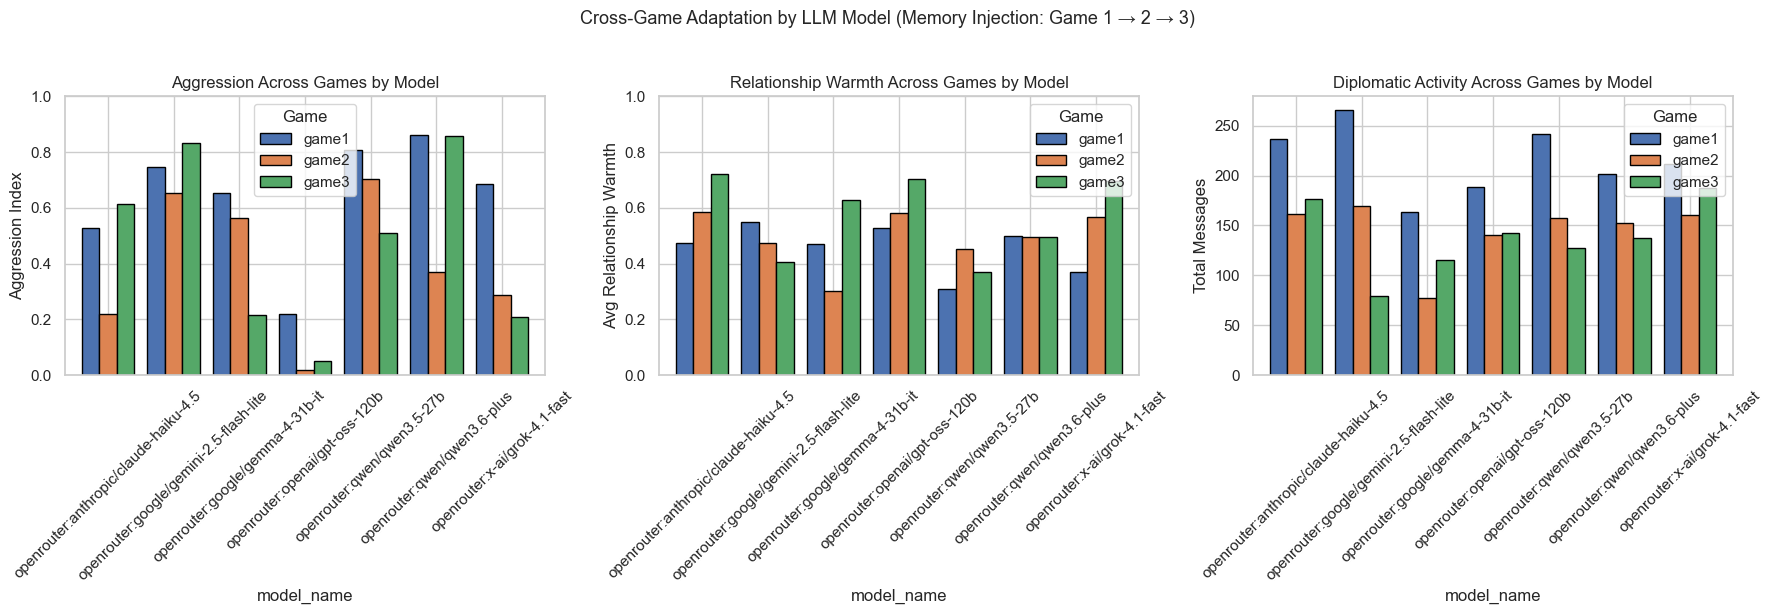

In [21]:
# Model-level cross-game adaptation
model_game_tactics = tactical_with_model.groupby(["model_name", "game", "order_type"]).size().unstack(fill_value=0)
for col in ["attack", "support", "hold"]:
    if col not in model_game_tactics.columns:
        model_game_tactics[col] = 0
model_game_tactics["total"] = model_game_tactics["attack"] + model_game_tactics["support"] + model_game_tactics["hold"]
model_game_tactics["aggression_index"] = model_game_tactics["attack"] / model_game_tactics["total"].replace(0, np.nan)
model_game_tactics = model_game_tactics.reset_index()

model_game_warmth = rel_with_model.groupby(["model_name", "game"])["warmth"].mean().reset_index()

model_game_msg = msg_with_model.groupby(["model_name", "game"]).size().reset_index(name="messages")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Aggression by model across games
agg_pivot = model_game_tactics.pivot(index="model_name", columns="game", values="aggression_index")
agg_pivot.plot(kind="bar", ax=axes[0], edgecolor="black", width=0.8)
axes[0].set_ylabel("Aggression Index")
axes[0].set_title("Aggression Across Games by Model")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Game")

# Warmth by model across games
warmth_pivot = model_game_warmth.pivot(index="model_name", columns="game", values="warmth")
warmth_pivot.plot(kind="bar", ax=axes[1], edgecolor="black", width=0.8)
axes[1].set_ylabel("Avg Relationship Warmth")
axes[1].set_title("Relationship Warmth Across Games by Model")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Game")

# Messages by model across games
msg_pivot = model_game_msg.pivot(index="model_name", columns="game", values="messages")
msg_pivot.plot(kind="bar", ax=axes[2], edgecolor="black", width=0.8)
axes[2].set_ylabel("Total Messages")
axes[2].set_title("Diplomatic Activity Across Games by Model")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(title="Game")

plt.suptitle("Cross-Game Adaptation by LLM Model (Memory Injection: Game 1 → 2 → 3)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
# 7. Composite Playstyle Profile
We combine all dimensions into a single radar chart per model, showing the multi-dimensional playstyle fingerprint.

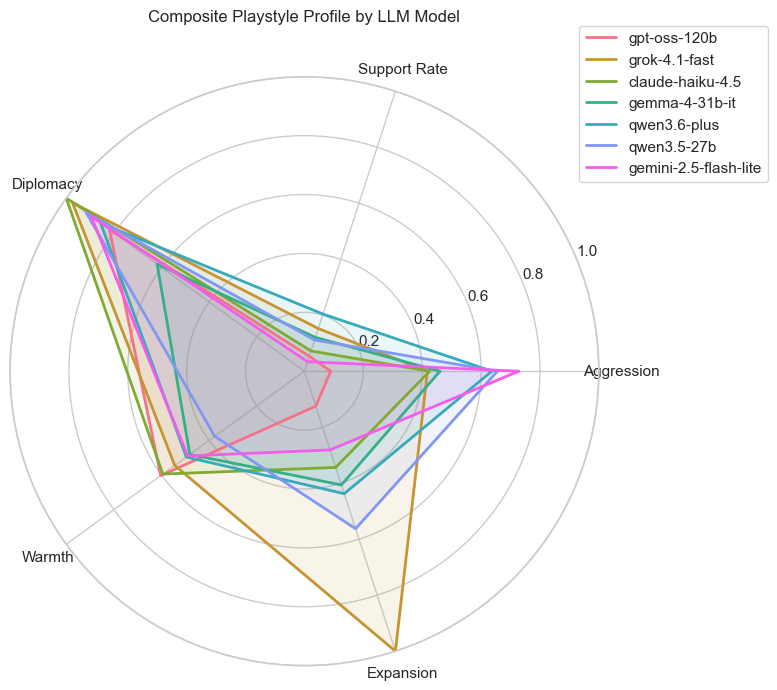

In [22]:
# Gather model-level metrics
model_agg = model_tactics[["model_name", "aggression_index", "support_rate"]].copy()

# Diplomatic volume (normalized)
model_msg_count = msg_with_model.groupby("model_name").size().reset_index(name="messages")
max_msg = model_msg_count["messages"].max()
model_msg_count["msg_norm"] = model_msg_count["messages"] / max_msg
model_agg = pd.merge(model_agg, model_msg_count[["model_name", "msg_norm"]], on="model_name")

# Relationship warmth
model_warmth = rel_with_model.groupby("model_name")["warmth"].mean().reset_index()
model_agg = pd.merge(model_agg, model_warmth, on="model_name")

# Average final SC (normalized)
sc_with_model = pd.merge(sc_df, model_df, on=["game", "power"], how="inner")
model_sc = sc_with_model.groupby("model_name")["final_sc"].mean().reset_index()
max_sc = model_sc["final_sc"].max()
model_sc["sc_norm"] = model_sc["final_sc"] / max_sc if max_sc > 0 else 0
model_agg = pd.merge(model_agg, model_sc[["model_name", "sc_norm"]], on="model_name")

# Radar chart
categories = ["Aggression", "Support Rate", "Diplomacy", "Warmth", "Expansion"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
color_palette = sns.color_palette("husl", len(model_agg))

for i, (_, row) in enumerate(model_agg.iterrows()):
    values = [row["aggression_index"], row["support_rate"],
              row["msg_norm"], row["warmth"], row["sc_norm"]]
    values += values[:1]
    short_name = row["model_name"].split("/")[-1]
    ax.plot(angles, values, linewidth=2, label=short_name, color=color_palette[i])
    ax.fill(angles, values, alpha=0.1, color=color_palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title("Composite Playstyle Profile by LLM Model", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 7.1 Composite Playstyle Profile by Power

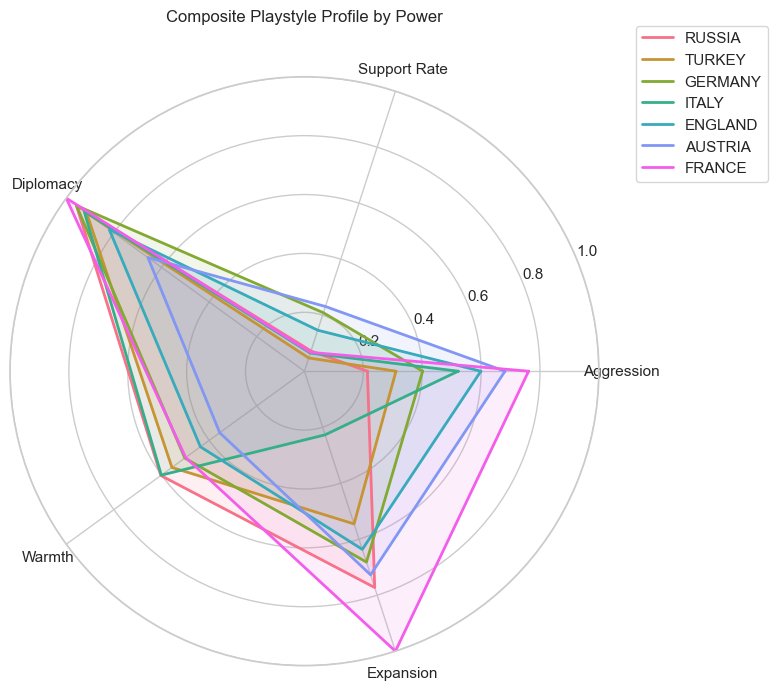

In [23]:
# Gather power-level metrics
power_agg = power_tactics[["power", "aggression_index", "support_rate"]].copy()

# Diplomatic volume (normalized)
power_msg_count = msg_df.groupby("sender").size().reset_index(name="messages")
power_msg_count.rename(columns={"sender": "power"}, inplace=True)
max_msg_p = power_msg_count["messages"].max()
power_msg_count["msg_norm"] = power_msg_count["messages"] / max_msg_p
power_agg = pd.merge(power_agg, power_msg_count[["power", "msg_norm"]], on="power", how="left").fillna(0)

# Relationship warmth
power_warmth = rel_df.groupby("power")["warmth"].mean().reset_index()
power_agg = pd.merge(power_agg, power_warmth, on="power", how="left").fillna(0.5)

# Average final SC (normalized)
power_sc_avg = sc_df.groupby("power")["final_sc"].mean().reset_index()
max_sc_p = power_sc_avg["final_sc"].max()
power_sc_avg["sc_norm"] = power_sc_avg["final_sc"] / max_sc_p if max_sc_p > 0 else 0
power_agg = pd.merge(power_agg, power_sc_avg[["power", "sc_norm"]], on="power", how="left").fillna(0)

# Radar chart
categories = ["Aggression", "Support Rate", "Diplomacy", "Warmth", "Expansion"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
color_palette = sns.color_palette("husl", len(power_agg))

for i, (_, row) in enumerate(power_agg.iterrows()):
    values = [row["aggression_index"], row["support_rate"],
              row["msg_norm"], row["warmth"], row["sc_norm"]]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["power"], color=color_palette[i])
    ax.fill(angles, values, alpha=0.1, color=color_palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title("Composite Playstyle Profile by Power", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
# 8. Playstyle vs. Game Outcomes
Does a particular playstyle lead to better results? We correlate aggression, diplomacy, and cooperation with final supply center counts.

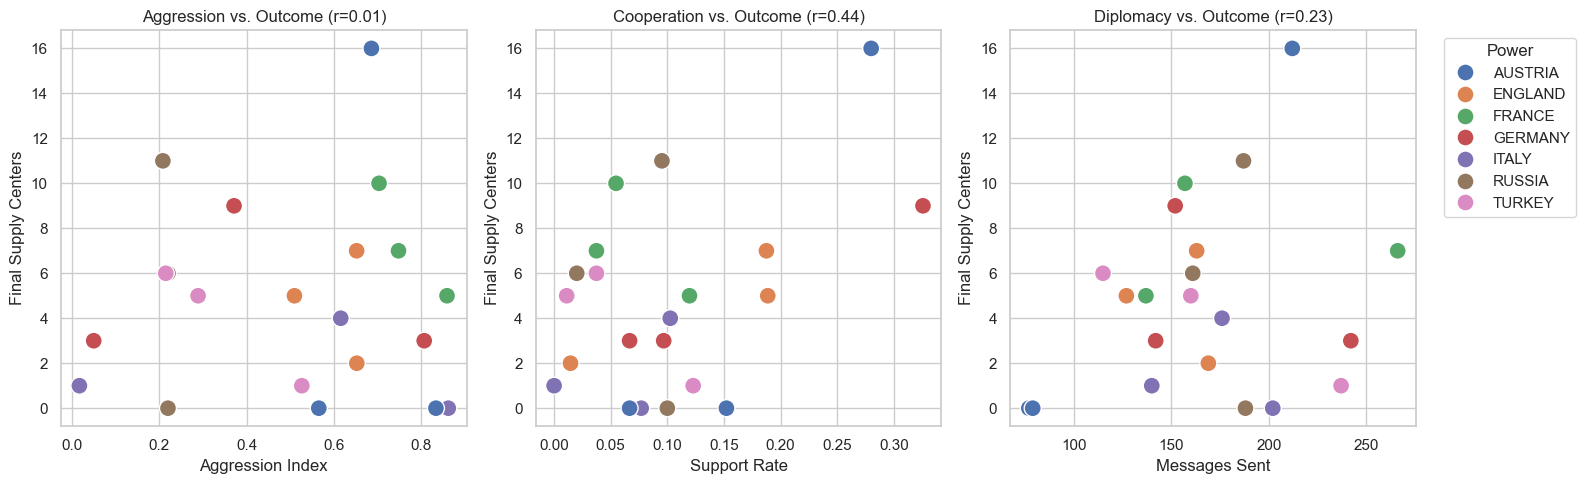


Correlation with final supply centers:
  Aggression:   r = 0.01
  Support rate: r = 0.44
  Messages:     r = 0.23


In [24]:
# Per-power-per-game aggression
power_game_tactics = tactical.groupby(["game", "power", "order_type"]).size().unstack(fill_value=0)
for col in ["attack", "support", "hold"]:
    if col not in power_game_tactics.columns:
        power_game_tactics[col] = 0
power_game_tactics["total"] = power_game_tactics["attack"] + power_game_tactics["support"] + power_game_tactics["hold"]
power_game_tactics["aggression_index"] = power_game_tactics["attack"] / power_game_tactics["total"].replace(0, np.nan)
power_game_tactics["support_rate"] = power_game_tactics["support"] / power_game_tactics["total"].replace(0, np.nan)
power_game_tactics = power_game_tactics.reset_index()

# Per-power-per-game messages
power_game_msg = msg_df.groupby(["game", "sender"]).size().reset_index(name="messages")
power_game_msg.rename(columns={"sender": "power"}, inplace=True)

# Merge all
outcome = pd.merge(power_game_tactics[["game", "power", "aggression_index", "support_rate"]],
                    sc_df, on=["game", "power"])
outcome = pd.merge(outcome, power_game_msg, on=["game", "power"], how="left").fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Aggression vs SC
sns.scatterplot(data=outcome, x="aggression_index", y="final_sc", hue="power",
                s=150, ax=axes[0], legend=False)
corr_agg = outcome["aggression_index"].corr(outcome["final_sc"])
axes[0].set_xlabel("Aggression Index")
axes[0].set_ylabel("Final Supply Centers")
axes[0].set_title(f"Aggression vs. Outcome (r={corr_agg:.2f})")

# Support rate vs SC
sns.scatterplot(data=outcome, x="support_rate", y="final_sc", hue="power",
                s=150, ax=axes[1], legend=False)
corr_sup = outcome["support_rate"].corr(outcome["final_sc"])
axes[1].set_xlabel("Support Rate")
axes[1].set_ylabel("Final Supply Centers")
axes[1].set_title(f"Cooperation vs. Outcome (r={corr_sup:.2f})")

# Messages vs SC
sns.scatterplot(data=outcome, x="messages", y="final_sc", hue="power", s=150, ax=axes[2])
corr_msg = outcome["messages"].corr(outcome["final_sc"])
axes[2].set_xlabel("Messages Sent")
axes[2].set_ylabel("Final Supply Centers")
axes[2].set_title(f"Diplomacy vs. Outcome (r={corr_msg:.2f})")
axes[2].legend(title="Power", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(f"\nCorrelation with final supply centers:")
print(f"  Aggression:   r = {corr_agg:.2f}")
print(f"  Support rate: r = {corr_sup:.2f}")
print(f"  Messages:     r = {corr_msg:.2f}")

## 8.1 Playstyle vs. Outcomes by LLM Model
The same correlations viewed at the model level — each point is one model in one game.

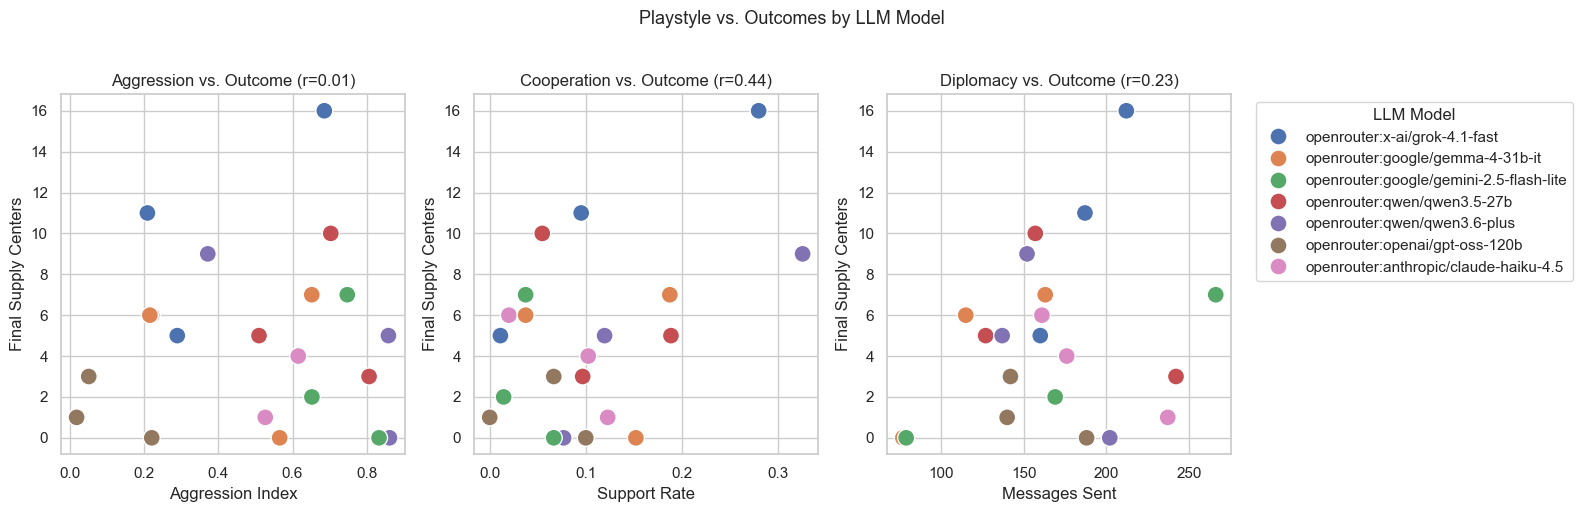


Correlation with final supply centers (by model):
  Aggression:   r = 0.01
  Support rate: r = 0.44
  Messages:     r = 0.23


In [25]:
outcome_model = pd.merge(outcome, model_df, on=["game", "power"], how="inner")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=outcome_model, x="aggression_index", y="final_sc", hue="model_name",
                s=150, ax=axes[0], legend=False)
corr_agg_m = outcome_model["aggression_index"].corr(outcome_model["final_sc"])
axes[0].set_xlabel("Aggression Index")
axes[0].set_ylabel("Final Supply Centers")
axes[0].set_title(f"Aggression vs. Outcome (r={corr_agg_m:.2f})")

sns.scatterplot(data=outcome_model, x="support_rate", y="final_sc", hue="model_name",
                s=150, ax=axes[1], legend=False)
corr_sup_m = outcome_model["support_rate"].corr(outcome_model["final_sc"])
axes[1].set_xlabel("Support Rate")
axes[1].set_ylabel("Final Supply Centers")
axes[1].set_title(f"Cooperation vs. Outcome (r={corr_sup_m:.2f})")

sns.scatterplot(data=outcome_model, x="messages", y="final_sc", hue="model_name", s=150, ax=axes[2])
corr_msg_m = outcome_model["messages"].corr(outcome_model["final_sc"])
axes[2].set_xlabel("Messages Sent")
axes[2].set_ylabel("Final Supply Centers")
axes[2].set_title(f"Diplomacy vs. Outcome (r={corr_msg_m:.2f})")
axes[2].legend(title="LLM Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.suptitle("Playstyle vs. Outcomes by LLM Model", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nCorrelation with final supply centers (by model):")
print(f"  Aggression:   r = {corr_agg_m:.2f}")
print(f"  Support rate: r = {corr_sup_m:.2f}")
print(f"  Messages:     r = {corr_msg_m:.2f}")

## 8.2 Grok 4.1 Fast: Error-Corrected Playstyle
Grok 4.1 Fast produced the most invalid orders in the experiment — coast-specification hallucinations like `F BUL/EC - GRE` that the game engine rejects, forcing those individual units to HOLD. In game 2 (Turkey), this affected up to 3 of ~5 units per phase from S1905M onward. This section compares Grok's playstyle profile with all 3 games vs. excluding game 2 to quantify the distortion.

/var/folders/94/c6n86z4n7mzdqsymcrqq9bhr0000gn/T/ipykernel_50892/3815980856.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


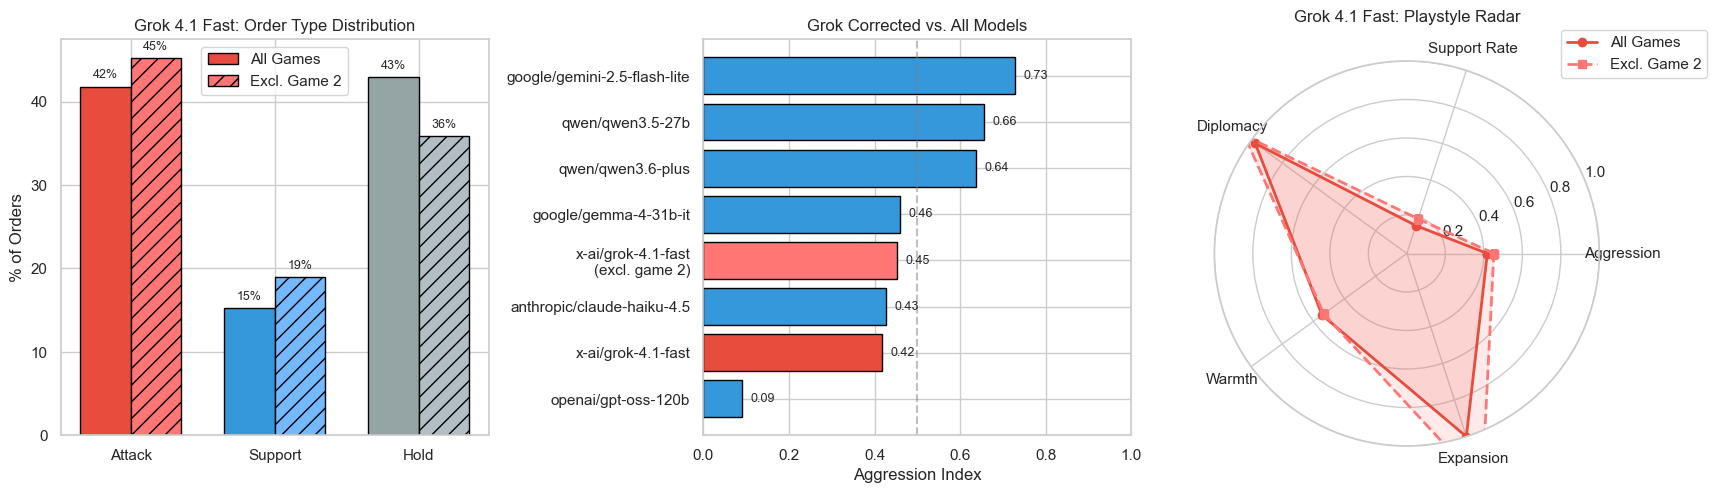

Grok 4.1 Fast aggression index:
  All games:      0.42
  Excl. game 2:   0.45  (+0.03)

Order breakdown:
order_type  All Games (count)  All Games (%)  Excl. Game 2 (count)  Excl. Game 2 (%)
    attack                181      41.801386                   155         45.189504
   support                 66      15.242494                    65         18.950437
      hold                186      42.956120                   123         35.860058


In [26]:
grok_model = "openrouter:x-ai/grok-4.1-fast"

# All games
grok_all = tactical_with_model[tactical_with_model["model_name"] == grok_model]
grok_all_counts = grok_all["order_type"].value_counts()
grok_all_total = grok_all_counts.sum()

# Excluding game 2
grok_no_g2 = tactical_with_model[(tactical_with_model["model_name"] == grok_model) &
                                  (tactical_with_model["game"] != "game2")]
grok_no_g2_counts = grok_no_g2["order_type"].value_counts()
grok_no_g2_total = grok_no_g2_counts.sum()

# Build comparison dataframe
order_types = ["attack", "support", "hold"]
comparison = pd.DataFrame({
    "order_type": order_types,
    "All Games (count)": [grok_all_counts.get(t, 0) for t in order_types],
    "All Games (%)": [grok_all_counts.get(t, 0) / grok_all_total * 100 for t in order_types],
    "Excl. Game 2 (count)": [grok_no_g2_counts.get(t, 0) for t in order_types],
    "Excl. Game 2 (%)": [grok_no_g2_counts.get(t, 0) / grok_no_g2_total * 100 for t in order_types],
})

agg_all = grok_all_counts.get("attack", 0) / grok_all_total
agg_no_g2 = grok_no_g2_counts.get("attack", 0) / grok_no_g2_total

# ── Radar: Grok with vs without game 2 ──
grok_msgs_all = msg_with_model[msg_with_model["model_name"] == grok_model]
grok_msgs_no_g2 = grok_msgs_all[grok_msgs_all["game"] != "game2"]

grok_warmth_all = rel_with_model[rel_with_model["model_name"] == grok_model]["warmth"].mean()
grok_warmth_no_g2 = rel_with_model[(rel_with_model["model_name"] == grok_model) &
                                    (rel_with_model["game"] != "game2")]["warmth"].mean()

grok_sc_all = sc_with_model[sc_with_model["model_name"] == grok_model]["final_sc"].mean()
grok_sc_no_g2 = sc_with_model[(sc_with_model["model_name"] == grok_model) &
                               (sc_with_model["game"] != "game2")]["final_sc"].mean()

support_all = grok_all_counts.get("support", 0) / grok_all_total
support_no_g2 = grok_no_g2_counts.get("support", 0) / grok_no_g2_total

msg_norm_all = len(grok_msgs_all) / max_msg
msg_norm_no_g2 = len(grok_msgs_no_g2) / (max_msg * 2 / 3)

sc_norm_all = grok_sc_all / max_sc if max_sc > 0 else 0
sc_norm_no_g2 = grok_sc_no_g2 / max_sc if max_sc > 0 else 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Order breakdown side-by-side ──
x = np.arange(len(order_types))
width = 0.35

bars1 = axes[0].bar(x - width/2, comparison["All Games (%)"], width,
                     label="All Games", color=["#e74c3c", "#3498db", "#95a5a6"], edgecolor="black")
bars2 = axes[0].bar(x + width/2, comparison["Excl. Game 2 (%)"], width,
                     label="Excl. Game 2", color=["#ff7675", "#74b9ff", "#b2bec3"],
                     edgecolor="black", hatch="//")
axes[0].set_ylabel("% of Orders")
axes[0].set_title("Grok 4.1 Fast: Order Type Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Attack", "Support", "Hold"])
axes[0].legend()
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.0f}%", ha="center", fontsize=9)
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.0f}%", ha="center", fontsize=9)

# ── Panel 2: Aggression index comparison with other models ──
model_agg_idx = model_tactics[["model_name", "aggression_index"]].copy()
model_agg_idx["model_name"] = model_agg_idx["model_name"].str.replace("openrouter:", "")
grok_corrected = pd.DataFrame([{"model_name": "x-ai/grok-4.1-fast\n(excl. game 2)",
                                  "aggression_index": agg_no_g2}])
model_agg_compare = pd.concat([model_agg_idx, grok_corrected], ignore_index=True)
model_agg_compare = model_agg_compare.sort_values("aggression_index", ascending=True)

bar_colors = []
for name in model_agg_compare["model_name"]:
    if "excl" in str(name):
        bar_colors.append("#ff7675")
    elif "grok" in str(name).lower():
        bar_colors.append("#e74c3c")
    else:
        bar_colors.append("#3498db")

axes[1].barh(model_agg_compare["model_name"], model_agg_compare["aggression_index"],
             color=bar_colors, edgecolor="black")
axes[1].set_xlabel("Aggression Index")
axes[1].set_title("Grok Corrected vs. All Models")
axes[1].set_xlim(0, 1)
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.5)
for i, (_, row) in enumerate(model_agg_compare.iterrows()):
    axes[1].text(row["aggression_index"] + 0.02, i, f"{row['aggression_index']:.2f}", va="center", fontsize=9)

# ── Panel 3: Radar comparison ──
categories = ["Aggression", "Support Rate", "Diplomacy", "Warmth", "Expansion"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

values_all = [agg_all, support_all, msg_norm_all, grok_warmth_all, sc_norm_all]
values_no_g2 = [agg_no_g2, support_no_g2, msg_norm_no_g2, grok_warmth_no_g2, sc_norm_no_g2]
values_all += values_all[:1]
values_no_g2 += values_no_g2[:1]

ax_radar = fig.add_axes(axes[2].get_position(), polar=True)
axes[2].set_visible(False)

ax_radar.plot(angles, values_all, linewidth=2, label="All Games", color="#e74c3c", marker="o")
ax_radar.fill(angles, values_all, alpha=0.15, color="#e74c3c")
ax_radar.plot(angles, values_no_g2, linewidth=2, label="Excl. Game 2", color="#ff7675",
              linestyle="--", marker="s")
ax_radar.fill(angles, values_no_g2, alpha=0.15, color="#ff7675")
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories)
ax_radar.set_ylim(0, 1)
ax_radar.set_title("Grok 4.1 Fast: Playstyle Radar", y=1.08)
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

print(f"Grok 4.1 Fast aggression index:")
print(f"  All games:      {agg_all:.2f}")
print(f"  Excl. game 2:   {agg_no_g2:.2f}  (+{(agg_no_g2 - agg_all):.2f})")
print(f"\nOrder breakdown:")
print(comparison.to_string(index=False))

---
# Conclusion

## Model Playstyle Fingerprints

The 7 LLM models show strikingly different tactical identities:

- **Gemini 2.5 Flash Lite** was the most aggressive (aggression index 0.73) with almost no supports (3.4%), playing a pure attack-or-hold style.
- **Qwen 3.5-27B** (0.66) and **Qwen 3.6 Plus** (0.64) were also aggressive, but Qwen 3.6 Plus stood out with the highest support rate (20.4%) — aggressive *and* cooperative.
- **GPT-oss-120B** was an extreme outlier: near-zero aggression (0.09) with only 15 attacks across all games, spending 86% of its orders on holds. This passivity was *intentional* — its diary explicitly records deliberate hold decisions.
- **Grok 4.1 Fast** (0.42) sat at the midpoint of the aggression spectrum. Its stats are somewhat distorted by persistent coast-specification hallucinations (e.g. `F BUL/EC - GRE`) that the engine rejected as invalid, forcing those units to HOLD. This was worst in game 2 (Turkey), where up to 3 of ~5 units were affected per phase. Excluding game 2, its aggression rises to 0.45 and support rate jumps from 15% to 19%. Despite these errors, Grok led in supply centers in both game 1 (16 SC as Austria) and game 3 (11 SC as Russia).
- **Claude Haiku 4.5** (0.43) and **Gemma 4-31B** (0.46) occupied genuine middle ground with no error-driven distortion.

## Cooperation as the Strongest Predictor

The correlation analysis reveals that **support rate is the strongest predictor of game success** (r = 0.44) — powers that coordinated with others through support orders ended up with more supply centers. Messaging volume also showed a positive correlation (r = 0.23), while aggression had essentially zero relationship with outcomes (r = 0.01). Attacking more did not translate to winning more; cooperating more did.

## Cross-Game Adaptation via Memory Injection

The three games show a clear trajectory:
- **Game 1** was the most aggressive (aggression 0.67) and diplomatically active (1,510 messages), with relationship warmth at 0.46.
- **Games 2 and 3** saw aggression drop to 0.42, messaging decline (1,016 → 963), but warmth steadily increase (0.50 → 0.59).

This suggests that memory injection led agents to adopt less aggressive, warmer relationships over successive games — they learned from prior conflict.

## Relationship Asymmetry

The average reciprocity gap was 0.14 (on a 0–1 scale), with the most extreme case being Austria labeling France as "Ally" while France labeled Austria as "Enemy" — a full 1.0 warmth gap persisting for multiple phases. At the model level, **Gemma 4-31B** and **Gemini Flash Lite** had the largest perception blindspots, while **GPT-oss-120B** was the most misread by others — its passive playstyle seems to confuse other models about its true intentions.